# 06 — SurfaceAlpha V5 Full Analysis

**Comprehensive analysis of the V5 model: volatility forecasting, regime classification, explainability (SHAP + surface attribution + MoE gating), and portfolio performance. All results are OOS from 28 walk-forward folds on the liquid_core universe (14 symbols, Apr 2018 – Apr 2025).**

### V5 Changes vs V4
- `macro_dim` 3 -> 6: added `spy_pct_from_ma200`, `spy_adx14`, `spy_atr_ratio` to ContextEncoder
- `lambda_reg` 0.15 -> 0.30: stronger regime classification supervision
- Selective baselines: GRU/TCN disabled; LSTM retained

**Prerequisites:** `make train-liquid-v5 evaluate-liquid-v5 backtest-liquid-v5 explain-liquid-v5 explain-regimes-v5`

In [22]:
import sys
import os
from pathlib import Path
if Path(os.getcwd()).name == 'notebooks':
    os.chdir('..')
sys.path.append(os.path.abspath('src'))
import warnings
warnings.filterwarnings('ignore')

import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
sns.set_palette('tab10')

# Paths
V5_DIR = Path('runs/liquid_core_v5/outputs')
V4_DIR = Path('runs/liquid_core_v4/outputs')
PRED5  = V5_DIR / 'predictions'
EVAL5  = V5_DIR / 'evaluation'
BT5    = V5_DIR / 'backtest'
EXP5   = V5_DIR / 'explain'

REGIME_NAMES  = ['bull_quiet','bull_volatile','bear_quiet','bear_volatile','sideways_quiet','sideways_volatile']
REGIME_COLORS = ['#2196F3','#FF9800','#F44336','#9C27B0','#4CAF50','#795548']

# Load core data
dfs = [pd.read_parquet(f) for f in sorted(glob.glob(str(PRED5 / 'fold_*_test_preds.parquet')))]
preds = pd.concat(dfs, ignore_index=True)
preds['date'] = pd.to_datetime(preds['date'])

eval5 = json.load(open(EVAL5 / 'evaluation_report.json'))
bt5   = json.load(open(BT5 / 'summary.json'))
bmark = json.load(open(BT5 / 'benchmark_summary.json'))
equity = pd.read_csv(BT5 / 'equity_curve.csv', parse_dates=['date'])

eval4 = json.load(open(V4_DIR / 'evaluation/evaluation_report.json'))
bt4   = json.load(open(V4_DIR / 'backtest/summary.json'))

pfold5   = pd.read_csv(EVAL5 / 'per_fold_metrics.csv')
pregime5 = pd.read_csv(EVAL5 / 'per_regime_metrics.csv')

fold_meta = []
for i in range(28):
    fold_path = V5_DIR / f'fold_{i}_summary.json'
    if fold_path.exists():
        s = json.load(open(fold_path))
        fold_meta.append({'fold': i, 'test_start': s.get('test_start',''), 'test_end': s.get('test_end','')})
fold_meta = pd.DataFrame(fold_meta)
if not fold_meta.empty:
    pfold5 = pfold5.merge(fold_meta, on='fold', how='left')

print(f"Predictions loaded: {len(preds):,} samples | {preds['date'].min().date()} - {preds['date'].max().date()}")
print(f"V5 outputs found: eval={EVAL5.exists()}, backtest={BT5.exists()}, explain={EXP5.exists()}")

Predictions loaded: 17,211 samples | 2018-04-12 - 2025-04-22
V5 outputs found: eval=True, backtest=True, explain=True


---
## 1. V4 vs V5 — Executive Summary

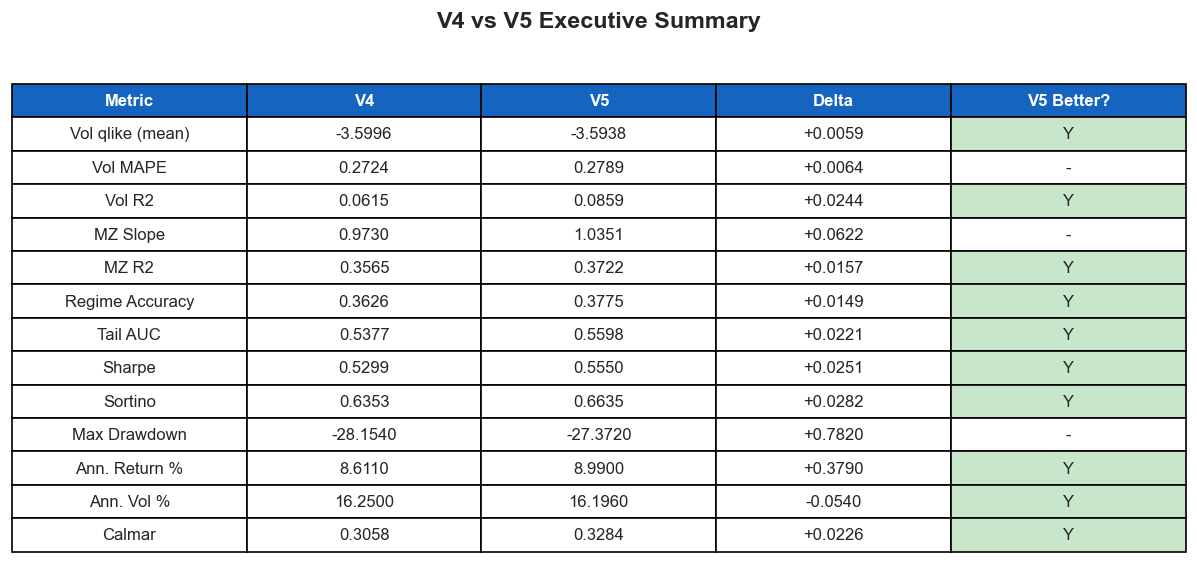

In [23]:
summary = {
    'Metric': [
        'Vol qlike (mean)', 'Vol MAPE', 'Vol R2', 'MZ Slope', 'MZ R2',
        'Regime Accuracy', 'Tail AUC',
        'Sharpe', 'Sortino', 'Max Drawdown', 'Ann. Return %', 'Ann. Vol %', 'Calmar',
    ],
    'V4': [
        eval4['aggregate']['vol_qlike']['mean'],
        eval4['aggregate']['vol_mape']['mean'],
        eval4['aggregate']['vol_r2']['mean'],
        eval4['mincer_zarnowitz']['slope'],
        eval4['mincer_zarnowitz']['r2'],
        eval4['aggregate']['clf_regime_accuracy']['mean'],
        eval4['aggregate']['clf_tail_auc']['mean'],
        bt4['sharpe'], bt4['sortino'], bt4['max_drawdown_pct'],
        bt4['ann_return_pct'], bt4['ann_vol_pct'], bt4['calmar'],
    ],
    'V5': [
        eval5['aggregate']['vol_qlike']['mean'],
        eval5['aggregate']['vol_mape']['mean'],
        eval5['aggregate']['vol_r2']['mean'],
        eval5['mincer_zarnowitz']['slope'],
        eval5['mincer_zarnowitz']['r2'],
        eval5['aggregate']['clf_regime_accuracy']['mean'],
        eval5['aggregate']['clf_tail_auc']['mean'],
        bt5['sharpe'], bt5['sortino'], bt5['max_drawdown_pct'],
        bt5['ann_return_pct'], bt5['ann_vol_pct'], bt5['calmar'],
    ],
}
df_sum = pd.DataFrame(summary).set_index('Metric')
df_sum['Delta'] = df_sum['V5'] - df_sum['V4']
df_sum['Better?'] = df_sum.apply(
    lambda r: 'Y' if (
        (r.name in ['Vol qlike (mean)','Vol R2','MZ R2','Regime Accuracy','Tail AUC',
                    'Sharpe','Sortino','Ann. Return %','Calmar'] and r['Delta'] > 0) or
        (r.name in ['Vol MAPE','Max Drawdown','Ann. Vol %'] and r['Delta'] < 0) or
        (r.name == 'MZ Slope' and abs(r['V5']-1.0) < abs(r['V4']-1.0))
    ) else '-',
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')
tbl = ax.table(
    cellText=[[m, f'{v4:.4f}', f'{v5:.4f}', f'{d:+.4f}', b]
               for m, v4, v5, d, b in zip(df_sum.index, df_sum['V4'], df_sum['V5'],
                                           df_sum['Delta'], df_sum['Better?'])],
    colLabels=['Metric', 'V4', 'V5', 'Delta', 'V5 Better?'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 4 and cell.get_text().get_text() == 'Y':
        cell.set_facecolor('#C8E6C9')
ax.set_title('V4 vs V5 Executive Summary', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## 2. Volatility Forecast: Mincer-Zarnowitz Calibration

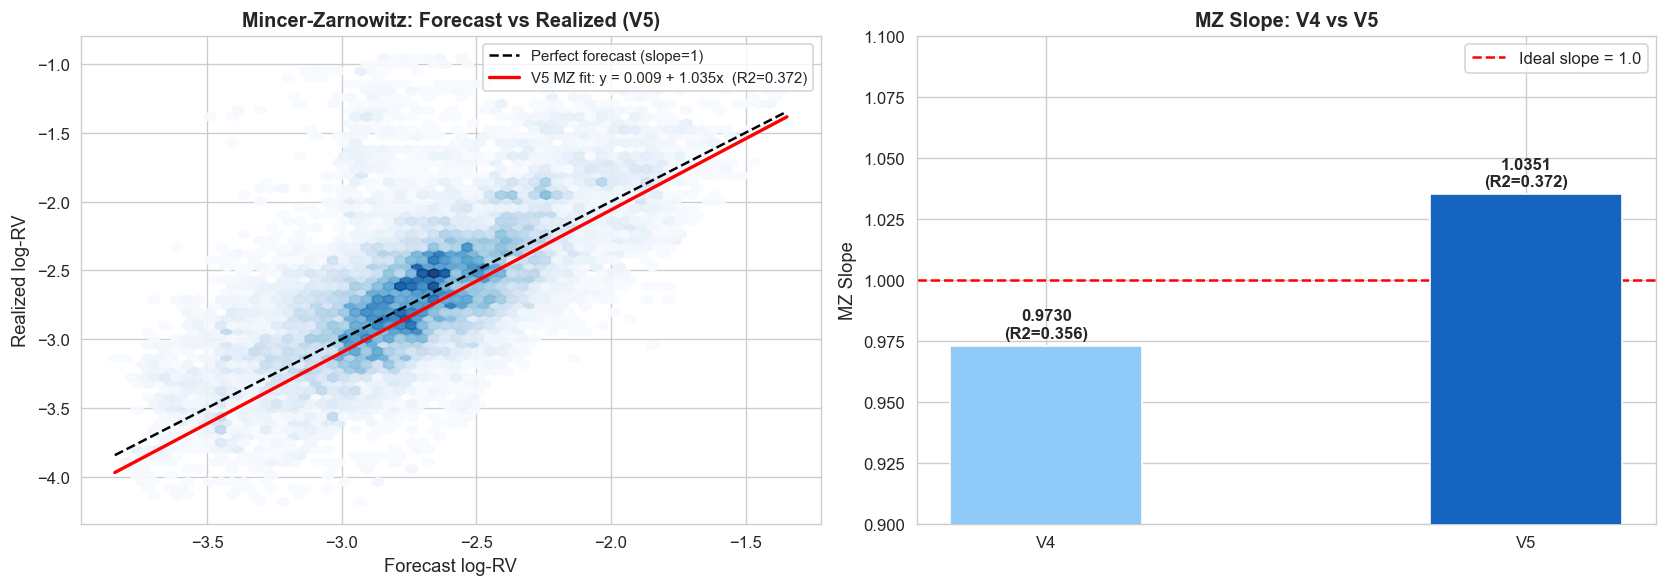

V5 MZ: intercept=0.00908, slope=1.03513, R2=0.3722, F=727.9, n=17,211
V4 MZ: slope=0.97296


In [24]:
log_rv_pred = preds['rv_pred'].values
log_rv_true = preds['target_rv'].values
mask = np.isfinite(log_rv_pred) & np.isfinite(log_rv_true)
x, y = log_rv_pred[mask], log_rv_true[mask]

mz5 = eval5['mincer_zarnowitz']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hexbin(x, y, gridsize=60, cmap='Blues', mincnt=1, alpha=0.9)
xlim = np.array([x.min(), x.max()])
ax.plot(xlim, xlim, 'k--', lw=1.5, label='Perfect forecast (slope=1)')
ax.plot(xlim, mz5['intercept'] + mz5['slope']*xlim, 'r-', lw=2,
        label=f"V5 MZ fit: y = {mz5['intercept']:.3f} + {mz5['slope']:.3f}x  (R2={mz5['r2']:.3f})")
ax.set_xlabel('Forecast log-RV', fontsize=11)
ax.set_ylabel('Realized log-RV', fontsize=11)
ax.set_title('Mincer-Zarnowitz: Forecast vs Realized (V5)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
versions = ['V4', 'V5']
slopes   = [eval4['mincer_zarnowitz']['slope'], mz5['slope']]
r2s      = [eval4['mincer_zarnowitz']['r2'], mz5['r2']]
bars = ax2.bar(versions, slopes, color=['#90CAF9', '#1565C0'], width=0.4, zorder=3)
ax2.axhline(1.0, color='red', linestyle='--', lw=1.5, label='Ideal slope = 1.0')
ax2.set_ylabel('MZ Slope', fontsize=11)
ax2.set_title('MZ Slope: V4 vs V5', fontsize=12, fontweight='bold')
ax2.set_ylim(0.9, 1.1)
ax2.legend()
for bar, v, r2 in zip(bars, slopes, r2s):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
             f'{v:.4f}\n(R2={r2:.3f})', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"V5 MZ: intercept={mz5['intercept']:.5f}, slope={mz5['slope']:.5f}, R2={mz5['r2']:.4f}, F={mz5['f_stat']:.1f}, n={mz5['n']:,}")
print(f"V4 MZ: slope={eval4['mincer_zarnowitz']['slope']:.5f}")

---
## 3. Volatility Forecast: Baseline Comparison

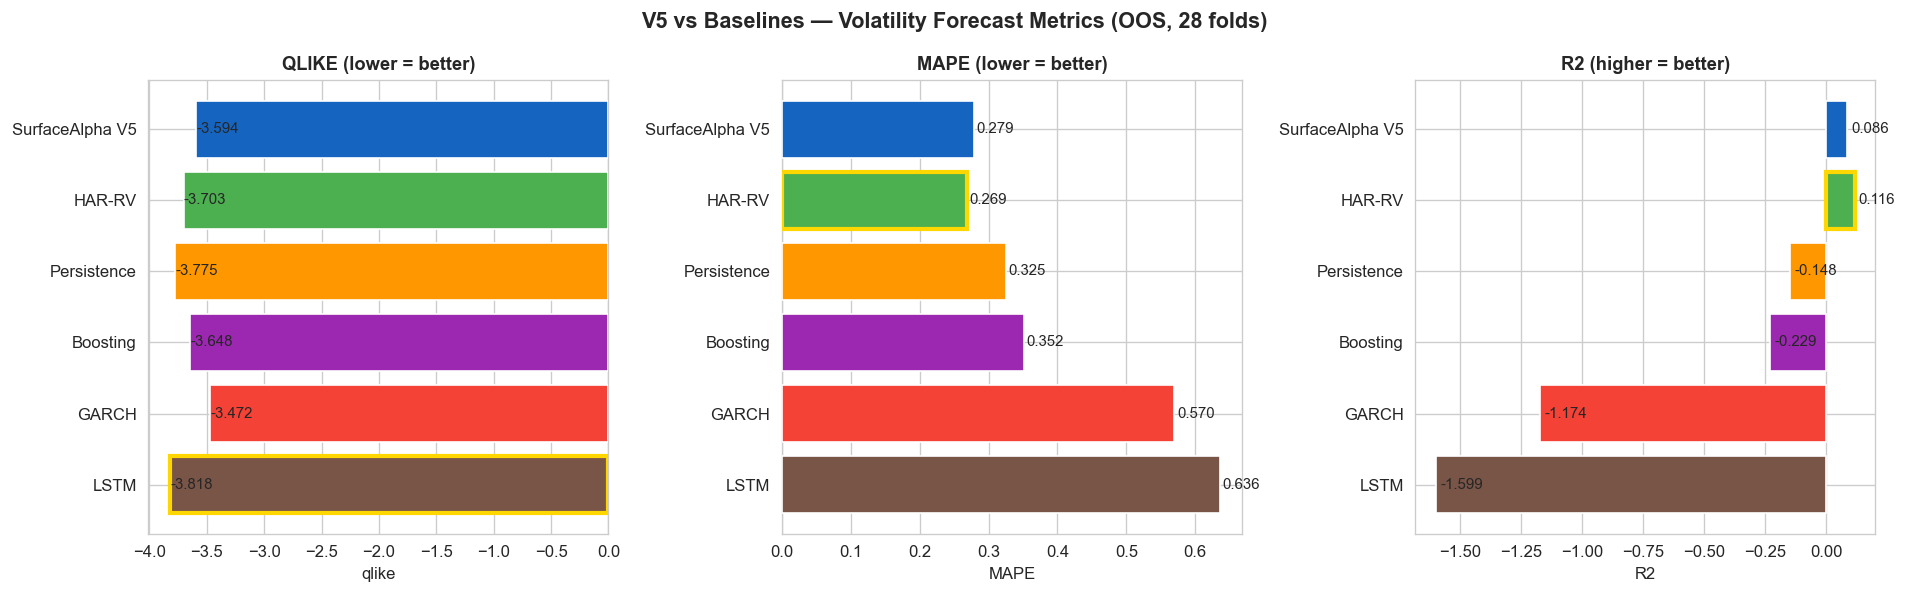

In [25]:
bl  = eval5['baseline_metrics']
agg = eval5['aggregate']

models = ['SurfaceAlpha V5', 'HAR-RV', 'Persistence', 'Boosting', 'GARCH', 'LSTM']
qlikes = [
    agg['vol_qlike']['mean'],
    bl['har_rv']['qlike']['mean'],
    bl['persistence']['qlike']['mean'],
    bl['boosting']['qlike']['mean'],
    bl['garch']['qlike']['mean'],
    bl['deep_ts_lstm']['qlike']['mean'],
]
mapes = [
    agg['vol_mape']['mean'],
    bl['har_rv']['mape']['mean'],
    bl['persistence']['mape']['mean'],
    bl['boosting']['mape']['mean'],
    bl['garch']['mape']['mean'],
    bl['deep_ts_lstm']['mape']['mean'],
]
r2s = [
    agg['vol_r2']['mean'],
    bl['har_rv']['r2']['mean'],
    bl['persistence']['r2']['mean'],
    bl['boosting']['r2']['mean'],
    bl['garch']['r2']['mean'],
    bl['deep_ts_lstm']['r2']['mean'],
]

colors_bl = ['#1565C0','#4CAF50','#FF9800','#9C27B0','#F44336','#795548']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, vals, title, better, ylabel in zip(
    axes,
    [qlikes, mapes, r2s],
    ['QLIKE (lower = better)', 'MAPE (lower = better)', 'R2 (higher = better)'],
    ['min','min','max'],
    ['qlike','MAPE','R2']
):
    bars = ax.barh(models[::-1], vals[::-1], color=colors_bl[::-1], zorder=3)
    best_val = min(vals) if better=='min' else max(vals)
    best_idx = vals.index(best_val)
    bars[len(models)-1-best_idx].set_edgecolor('gold')
    bars[len(models)-1-best_idx].set_linewidth(2.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(ylabel)
    for bar, val in zip(bars, vals[::-1]):
        ax.text(val + (max(vals)-min(vals))*0.01, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('V5 vs Baselines — Volatility Forecast Metrics (OOS, 28 folds)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Volatility Forecast: Fold Stability

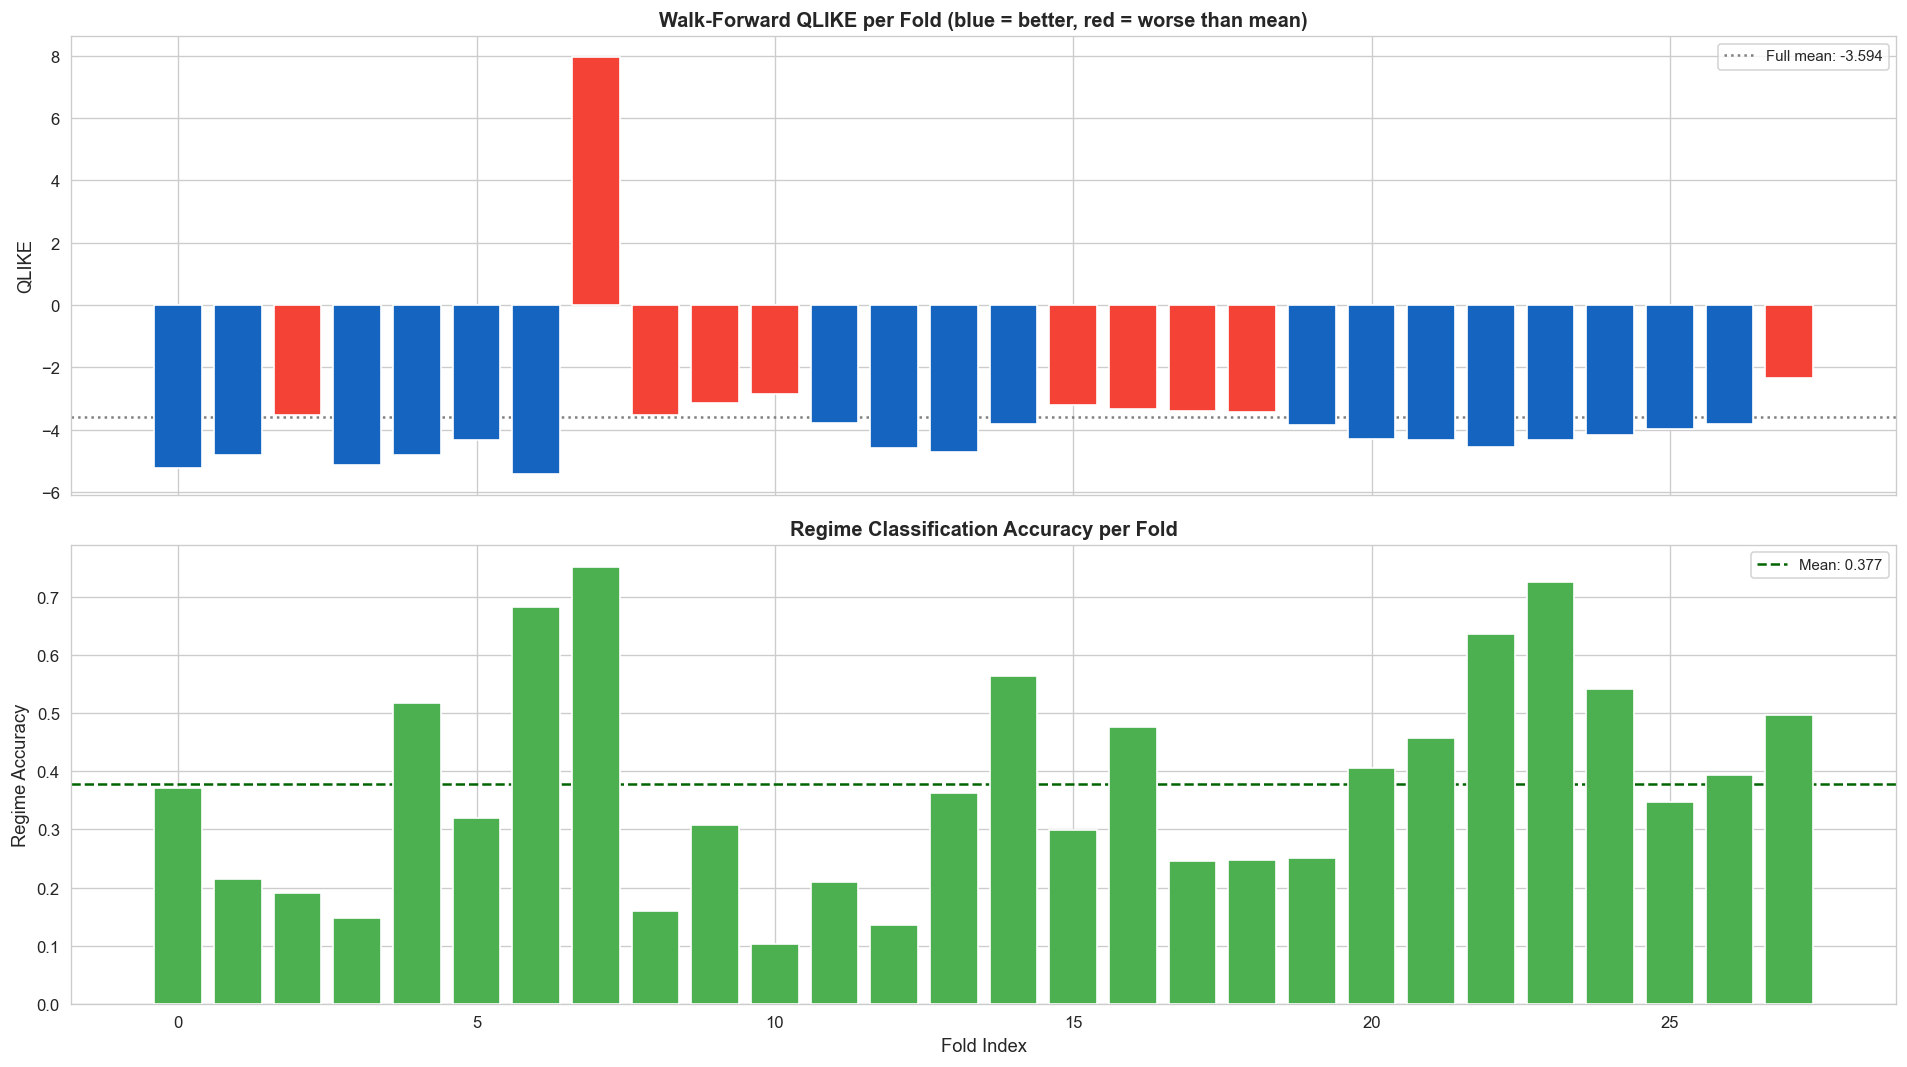

 fold test_start  vol_qlike  vol_mape  vol_r2  clf_regime_accuracy
    0 2018-04-12    -5.2132    0.3185 -0.0471               0.3719
    1 2018-07-12    -4.7942    0.4290 -0.0853               0.2154
    2 2018-10-10    -3.5255    0.3123 -0.8798               0.1905
    3 2019-01-14    -5.1156    0.3233 -0.3864               0.1477
    4 2019-04-15    -4.8226    0.2545 -0.4666               0.5170
    5 2019-07-16    -4.3308    0.2679 -0.7993               0.3205
    6 2019-10-15    -5.4197    0.3018  0.1660               0.6825
    7 2020-01-15     7.9628    0.5996 -1.9147               0.7528
    8 2020-04-16    -3.5183    0.3183  0.3131               0.1591
    9 2020-07-17    -3.1420    0.3239 -0.3203               0.3075
   10 2020-10-15    -2.8433    0.3878 -0.2952               0.1023
   11 2021-01-15    -3.7767    0.2723  0.1511               0.2099
   12 2021-04-19    -4.5945    0.2472  0.5305               0.1363
   13 2021-07-19    -4.7101    0.1859  0.6217               0.

In [26]:
if 'test_start' in pfold5.columns:
    pfold5['test_start_dt'] = pd.to_datetime(pfold5['test_start'])
    pfold5['year'] = pfold5['test_start_dt'].dt.year

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

ax = axes[0]
mean_qlike = pfold5['vol_qlike'].mean()
bar_colors = ['#F44336' if q > mean_qlike else '#1565C0' for q in pfold5['vol_qlike']]
ax.bar(pfold5['fold'], pfold5['vol_qlike'], color=bar_colors, zorder=3)
ax.axhline(mean_qlike, color='gray', linestyle=':', lw=1.5, label=f'Full mean: {mean_qlike:.3f}')
ax.set_ylabel('QLIKE', fontsize=11)
ax.set_title('Walk-Forward QLIKE per Fold (blue = better, red = worse than mean)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

ax2 = axes[1]
if 'clf_regime_accuracy' in pfold5.columns:
    mean_acc = pfold5['clf_regime_accuracy'].mean()
    ax2.bar(pfold5['fold'], pfold5['clf_regime_accuracy'], color='#4CAF50', zorder=3)
    ax2.axhline(mean_acc, color='darkgreen', linestyle='--', lw=1.5, label=f'Mean: {mean_acc:.3f}')
    ax2.set_ylabel('Regime Accuracy', fontsize=11)
    ax2.legend(fontsize=9)
ax2.set_xlabel('Fold Index', fontsize=11)
ax2.set_title('Regime Classification Accuracy per Fold', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

display_cols = [c for c in ['fold','test_start','vol_qlike','vol_mape','vol_r2','clf_regime_accuracy'] if c in pfold5.columns]
print(pfold5[display_cols].round(4).to_string(index=False))

---
## 5. Volatility Forecast: Per-Regime Breakdown

pregime5_m columns: ['regime', 'qlike_v5', 'ql_v5', 'mape_v5', 'r2_v5', 'bias_v5', 'rmse_v5', 'n_v5', 'qlike_v4', 'ql_v4', 'mape_v4', 'r2_v4', 'bias_v4', 'rmse_v4', 'n_v4']


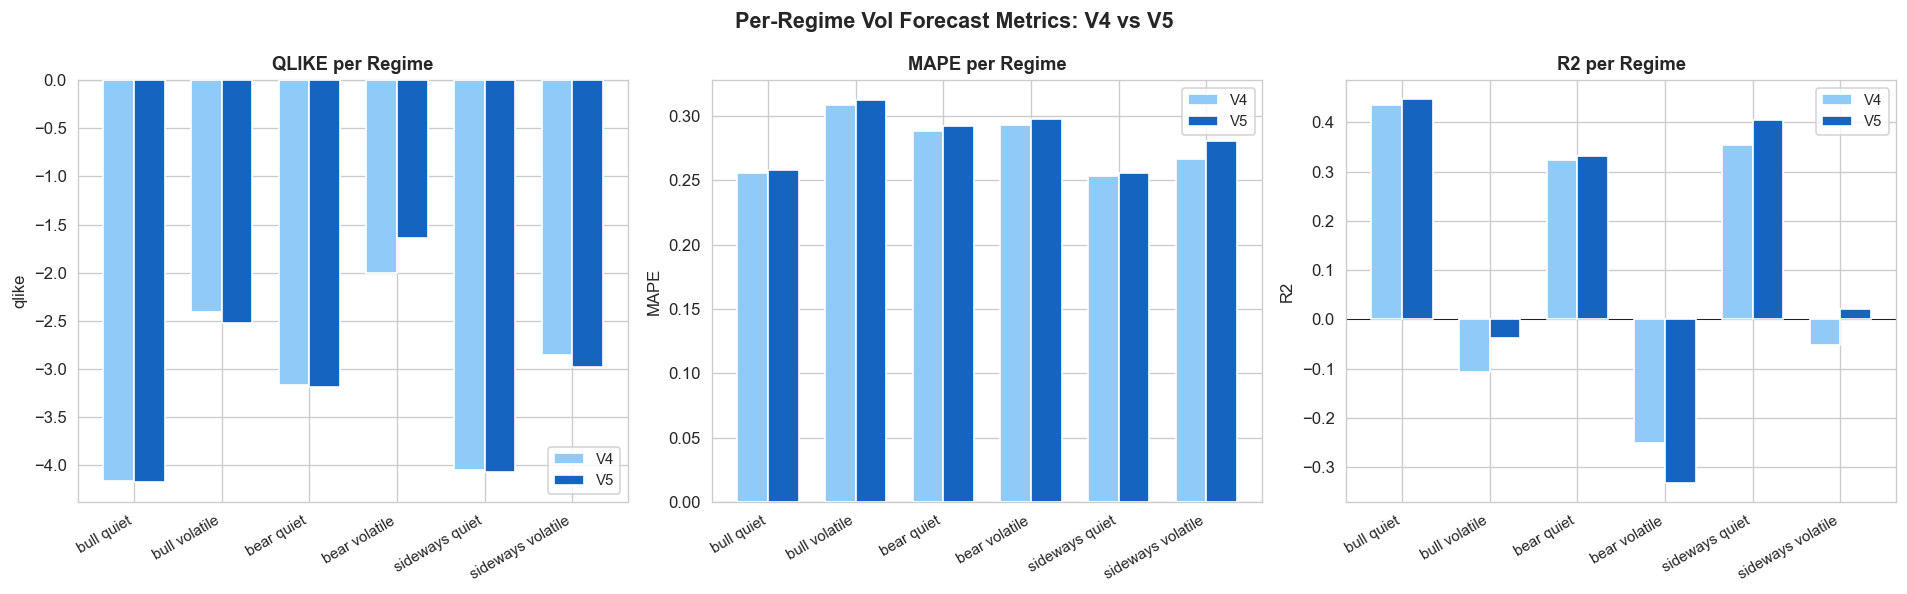

Per-regime qlike comparison:
  bull_quiet           n= 5515  V4=-4.1590  V5=-4.1731  D=-0.0141  V5 better
  bull_volatile        n= 1186  V4=-2.4034  V5=-2.5176  D=-0.1142  V5 better
  bear_quiet           n= 1163  V4=-3.1701  V5=-3.1839  D=-0.0137  V5 better
  bear_volatile        n= 1427  V4=-2.0026  V5=-1.6374  D=+0.3653  V5 worse
  sideways_quiet       n= 6588  V4=-4.0448  V5=-4.0656  D=-0.0208  V5 better
  sideways_volatile    n= 1332  V4=-2.8603  V5=-2.9794  D=-0.1191  V5 better


In [27]:
# Merge V5 and V4 per-regime metrics
# After merge suffixes: _v5, _v4 for overlapping columns
pregime4 = pd.read_csv(V4_DIR / 'evaluation/per_regime_metrics.csv')
pregime5_m = pregime5.merge(pregime4, on='regime', suffixes=('_v5','_v4'))

print(f"pregime5_m columns: {list(pregime5_m.columns)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(REGIME_NAMES))
w = 0.35

for ax, m4, m5, title, lbl in zip(
    axes,
    ['qlike_v4','mape_v4','r2_v4'],
    ['qlike_v5','mape_v5','r2_v5'],
    ['QLIKE per Regime','MAPE per Regime','R2 per Regime'],
    ['qlike','MAPE','R2']
):
    if m4 not in pregime5_m.columns or m5 not in pregime5_m.columns:
        ax.set_title(f'{title} (columns not found)')
        continue
    v4_vals = [pregime5_m.loc[pregime5_m.regime==r, m4].values[0]
               if (pregime5_m.regime==r).any() else 0 for r in REGIME_NAMES]
    v5_vals = [pregime5_m.loc[pregime5_m.regime==r, m5].values[0]
               if (pregime5_m.regime==r).any() else 0 for r in REGIME_NAMES]
    ax.bar(x - w/2, v4_vals, w, label='V4', color='#90CAF9', zorder=3)
    ax.bar(x + w/2, v5_vals, w, label='V5', color='#1565C0', zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels([r.replace('_',' ') for r in REGIME_NAMES], rotation=30, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(lbl)
    ax.legend(fontsize=9)
    ax.axhline(0, color='k', lw=0.5)

plt.suptitle('Per-Regime Vol Forecast Metrics: V4 vs V5', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

if 'qlike_v4' in pregime5_m.columns and 'qlike_v5' in pregime5_m.columns:
    n_col = 'n_v5' if 'n_v5' in pregime5_m.columns else 'n'
    print('Per-regime qlike comparison:')
    for r in REGIME_NAMES:
        mask_r = pregime5_m.regime == r
        if not mask_r.any():
            continue
        v4q = pregime5_m.loc[mask_r, 'qlike_v4'].values[0]
        v5q = pregime5_m.loc[mask_r, 'qlike_v5'].values[0]
        n   = pregime5_m.loc[mask_r, n_col].values[0] if n_col in pregime5_m.columns else 0
        delta = v5q - v4q
        better = 'V5 better' if delta < 0 else 'V5 worse'
        print(f'  {r:20s} n={int(n):5d}  V4={v4q:.4f}  V5={v5q:.4f}  D={delta:+.4f}  {better}')

---
## 6. Regime Classification: Confusion Matrix

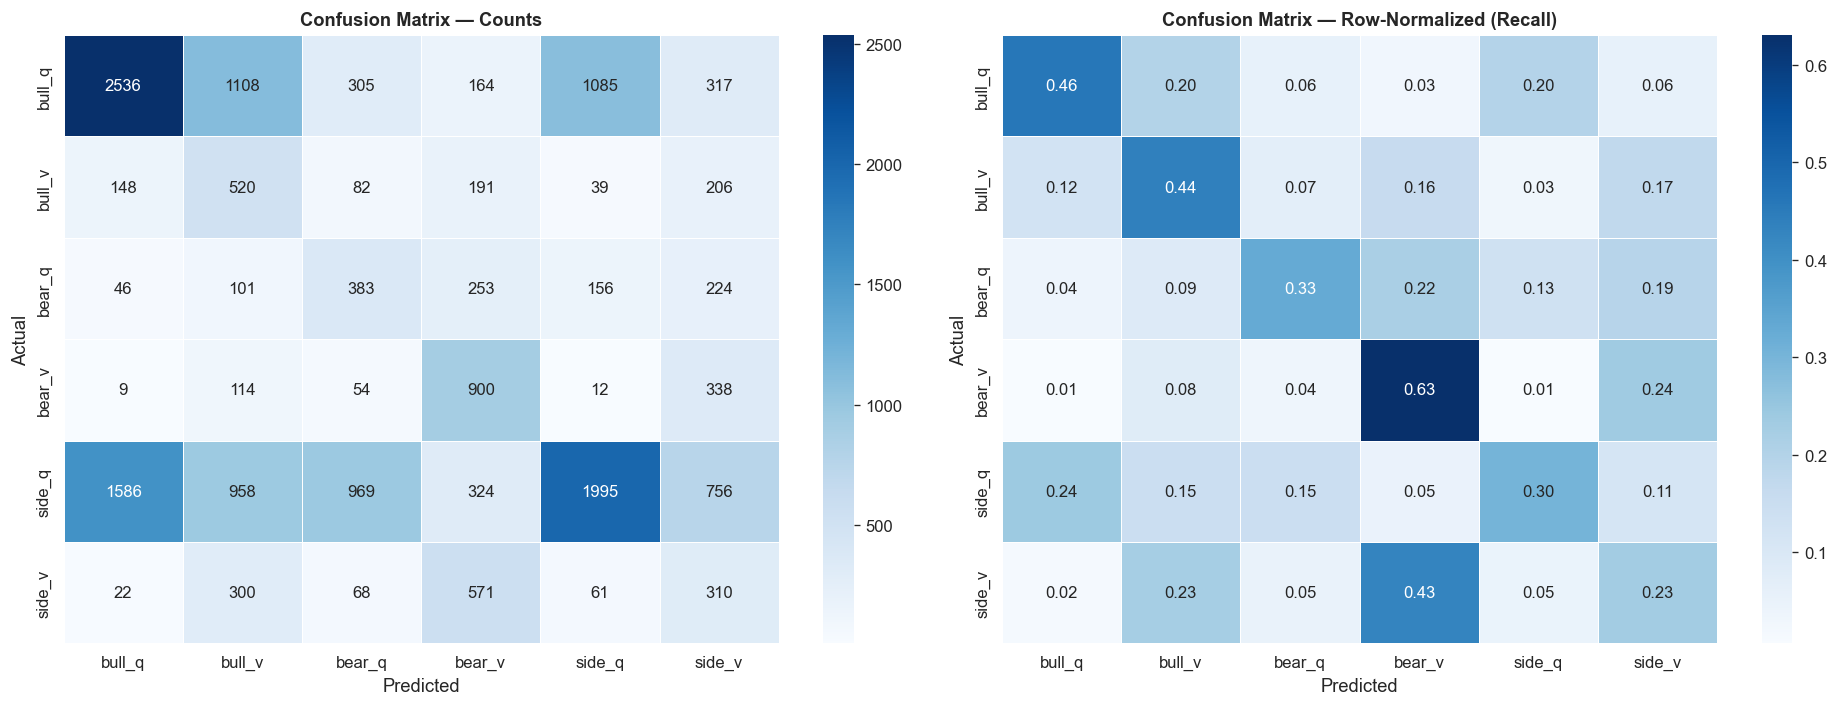

Per-class accuracy:
  bull_quiet            recall=0.460  n_true= 5515  n_pred= 4347
  bull_volatile         recall=0.438  n_true= 1186  n_pred= 3101
  bear_quiet            recall=0.329  n_true= 1163  n_pred= 1861
  bear_volatile         recall=0.631  n_true= 1427  n_pred= 2403
  sideways_quiet        recall=0.303  n_true= 6588  n_pred= 3348
  sideways_volatile     recall=0.233  n_true= 1332  n_pred= 2151


In [28]:
from sklearn.metrics import confusion_matrix

cm      = confusion_matrix(preds['target_regime'], preds['regime_pred'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
short_names = ['bull_q','bull_v','bear_q','bear_v','side_q','side_v']

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Confusion Matrix — Counts', 'Confusion Matrix — Row-Normalized (Recall)'],
    ['d', '.2f']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('Per-class accuracy:')
for k, name in enumerate(REGIME_NAMES):
    acc    = cm_norm[k, k]
    n_true = cm[k].sum()
    n_pred = cm[:, k].sum()
    print(f'  {name:20s}  recall={acc:.3f}  n_true={n_true:5d}  n_pred={n_pred:5d}')

---
## 7. Regime Classification: Expert Diversity (MoE Collapse Diagnostic)

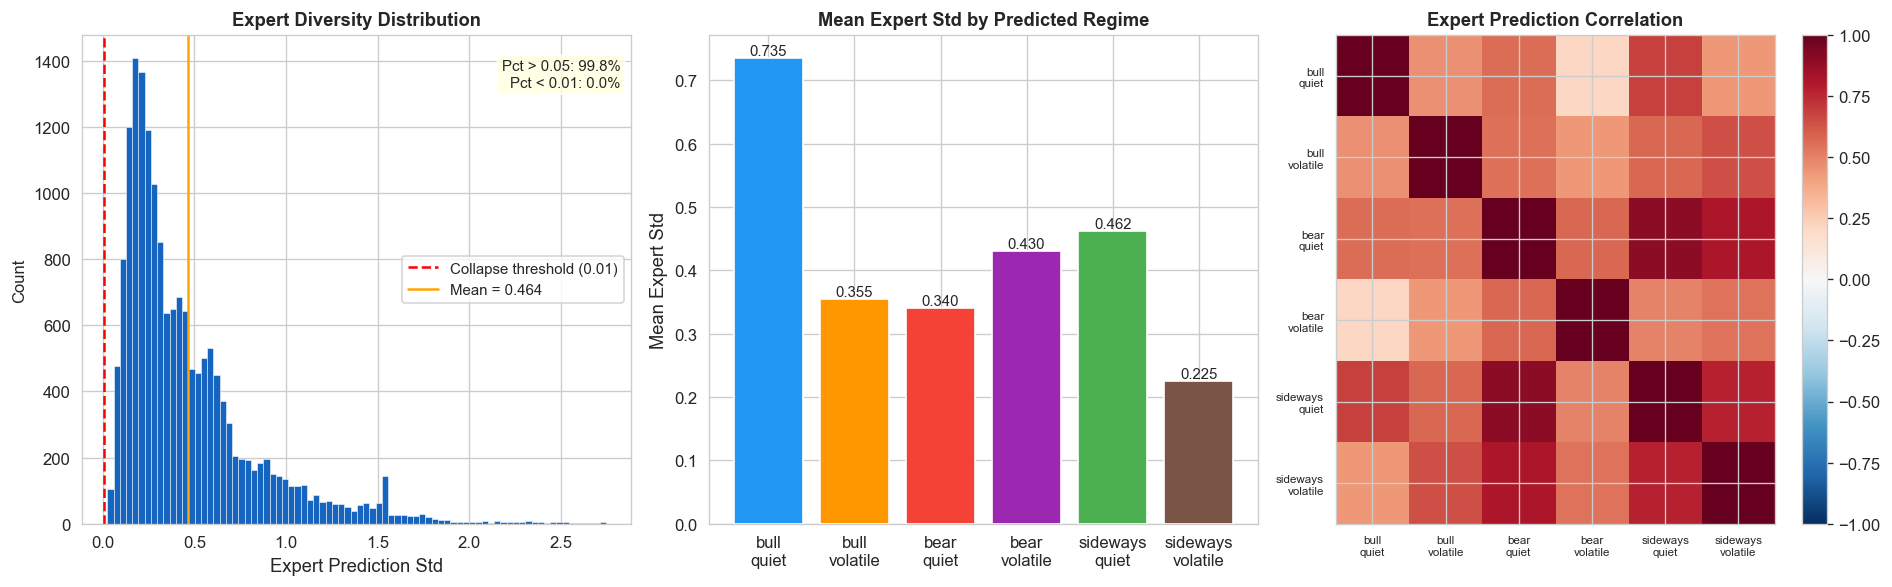

In [29]:
# Expert columns are expert_0, expert_1, ..., expert_5 (NOT expert_pred_0)
expert_cols = [f'expert_{k}' for k in range(6)]
expert_cols = [c for c in expert_cols if c in preds.columns]

if expert_cols:
    experts = preds[expert_cols].values
    expert_std   = experts.std(axis=1)
    expert_range = experts.max(axis=1) - experts.min(axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    ax = axes[0]
    ax.hist(expert_std, bins=80, color='#1565C0', edgecolor='white', linewidth=0.3)
    ax.axvline(0.01, color='red', lw=1.5, linestyle='--', label='Collapse threshold (0.01)')
    ax.axvline(expert_std.mean(), color='orange', lw=1.5, linestyle='-',
               label=f'Mean = {expert_std.mean():.3f}')
    ax.set_xlabel('Expert Prediction Std', fontsize=11)
    ax.set_ylabel('Count')
    ax.set_title('Expert Diversity Distribution', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.text(0.98, 0.95, f'Pct > 0.05: {(expert_std > 0.05).mean()*100:.1f}%\nPct < 0.01: {(expert_std < 0.01).mean()*100:.1f}%',
            transform=ax.transAxes, va='top', ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    ax2 = axes[1]
    regime_stds = [expert_std[preds['regime_pred']==k].mean() for k in range(6)]
    bars = ax2.bar([r.replace('_','\n') for r in REGIME_NAMES], regime_stds, color=REGIME_COLORS, zorder=3)
    ax2.set_ylabel('Mean Expert Std', fontsize=11)
    ax2.set_title('Mean Expert Std by Predicted Regime', fontsize=11, fontweight='bold')
    for bar, v in zip(bars, regime_stds):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{v:.3f}', ha='center', fontsize=9)

    ax3 = axes[2]
    corr_m = preds[expert_cols].corr().values
    im = ax3.imshow(corr_m, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax3)
    ax3.set_xticks(range(len(expert_cols)))
    ax3.set_yticks(range(len(expert_cols)))
    short = [r.replace('_','\n') for r in REGIME_NAMES[:len(expert_cols)]]
    ax3.set_xticklabels(short, fontsize=7)
    ax3.set_yticklabels(short, fontsize=7)
    ax3.set_title('Expert Prediction Correlation', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('Expert columns (expert_0..5) not found in predictions.')

---
## 8. Explainability: SHAP Feature Importance (V4 vs V5)

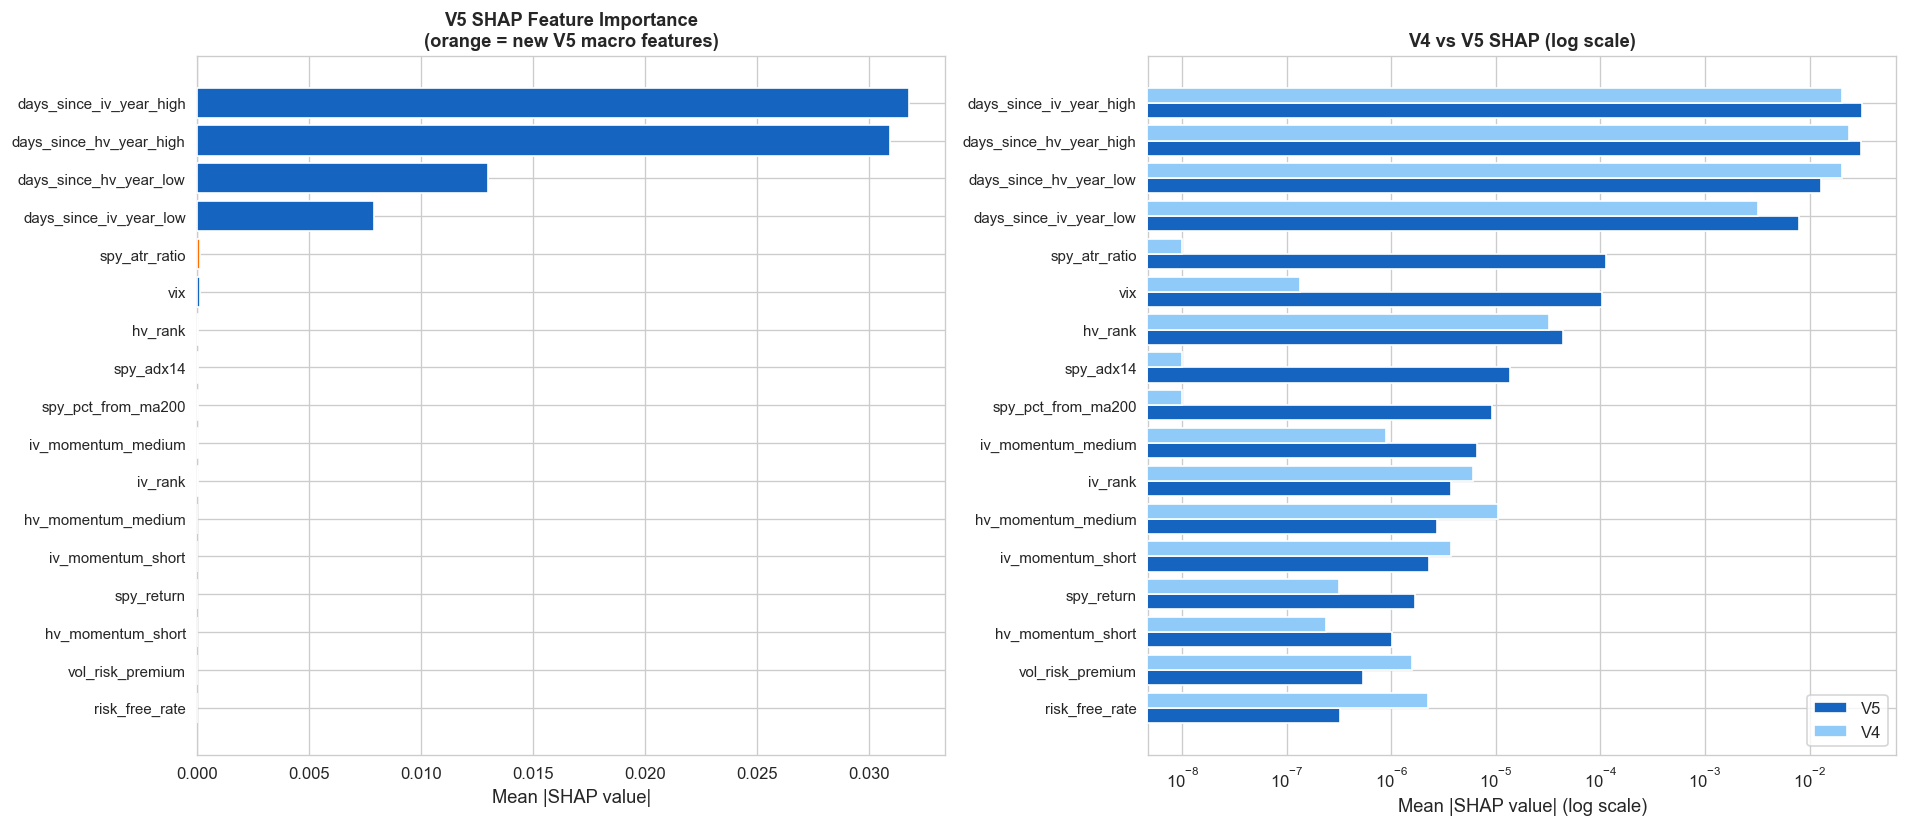

In [30]:
shap5_path = EXP5 / 'shap_importance.json'
shap4_path = V4_DIR / 'explain/shap_importance.json'

# Always define new_v5 (section 9 depends on it)
new_v5 = {'spy_pct_from_ma200', 'spy_adx14', 'spy_atr_ratio'}

if shap5_path.exists() and shap4_path.exists():
    shap5 = json.load(open(shap5_path))
    shap4 = json.load(open(shap4_path))

    all_features = list(shap5.keys())
    v5_vals = [shap5[f] for f in all_features]
    v4_vals = [shap4.get(f, 0.0) for f in all_features]

    order = np.argsort(v5_vals)[::-1]
    features_sorted = [all_features[i] for i in order]
    v5_sorted = [v5_vals[i] for i in order]
    v4_sorted = [v4_vals[i] for i in order]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    ax = axes[0]
    y_pos = np.arange(len(features_sorted))
    colors_shap = ['#FF6F00' if f in new_v5 else '#1565C0' for f in features_sorted]
    ax.barh(y_pos, v5_sorted, color=colors_shap, zorder=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features_sorted, fontsize=9)
    ax.set_xlabel('Mean |SHAP value|', fontsize=11)
    ax.set_title('V5 SHAP Feature Importance\n(orange = new V5 macro features)', fontsize=11, fontweight='bold')
    ax.invert_yaxis()

    ax2 = axes[1]
    v5_plot = np.array(v5_sorted) + 1e-8
    v4_plot = np.array(v4_sorted) + 1e-8
    y = np.arange(len(features_sorted))
    ax2.barh(y + 0.2, v5_plot, 0.4, color='#1565C0', label='V5', zorder=3)
    ax2.barh(y - 0.2, v4_plot, 0.4, color='#90CAF9', label='V4', zorder=3)
    ax2.set_xscale('log')
    ax2.set_yticks(y)
    ax2.set_yticklabels(features_sorted, fontsize=9)
    ax2.set_xlabel('Mean |SHAP value| (log scale)', fontsize=11)
    ax2.set_title('V4 vs V5 SHAP (log scale)', fontsize=11, fontweight='bold')
    ax2.invert_yaxis()
    ax2.legend(fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print(f'SHAP files not found. Checked: {shap5_path}')

---
## 9. Explainability: Per-Regime SHAP (regime_0 through regime_5)

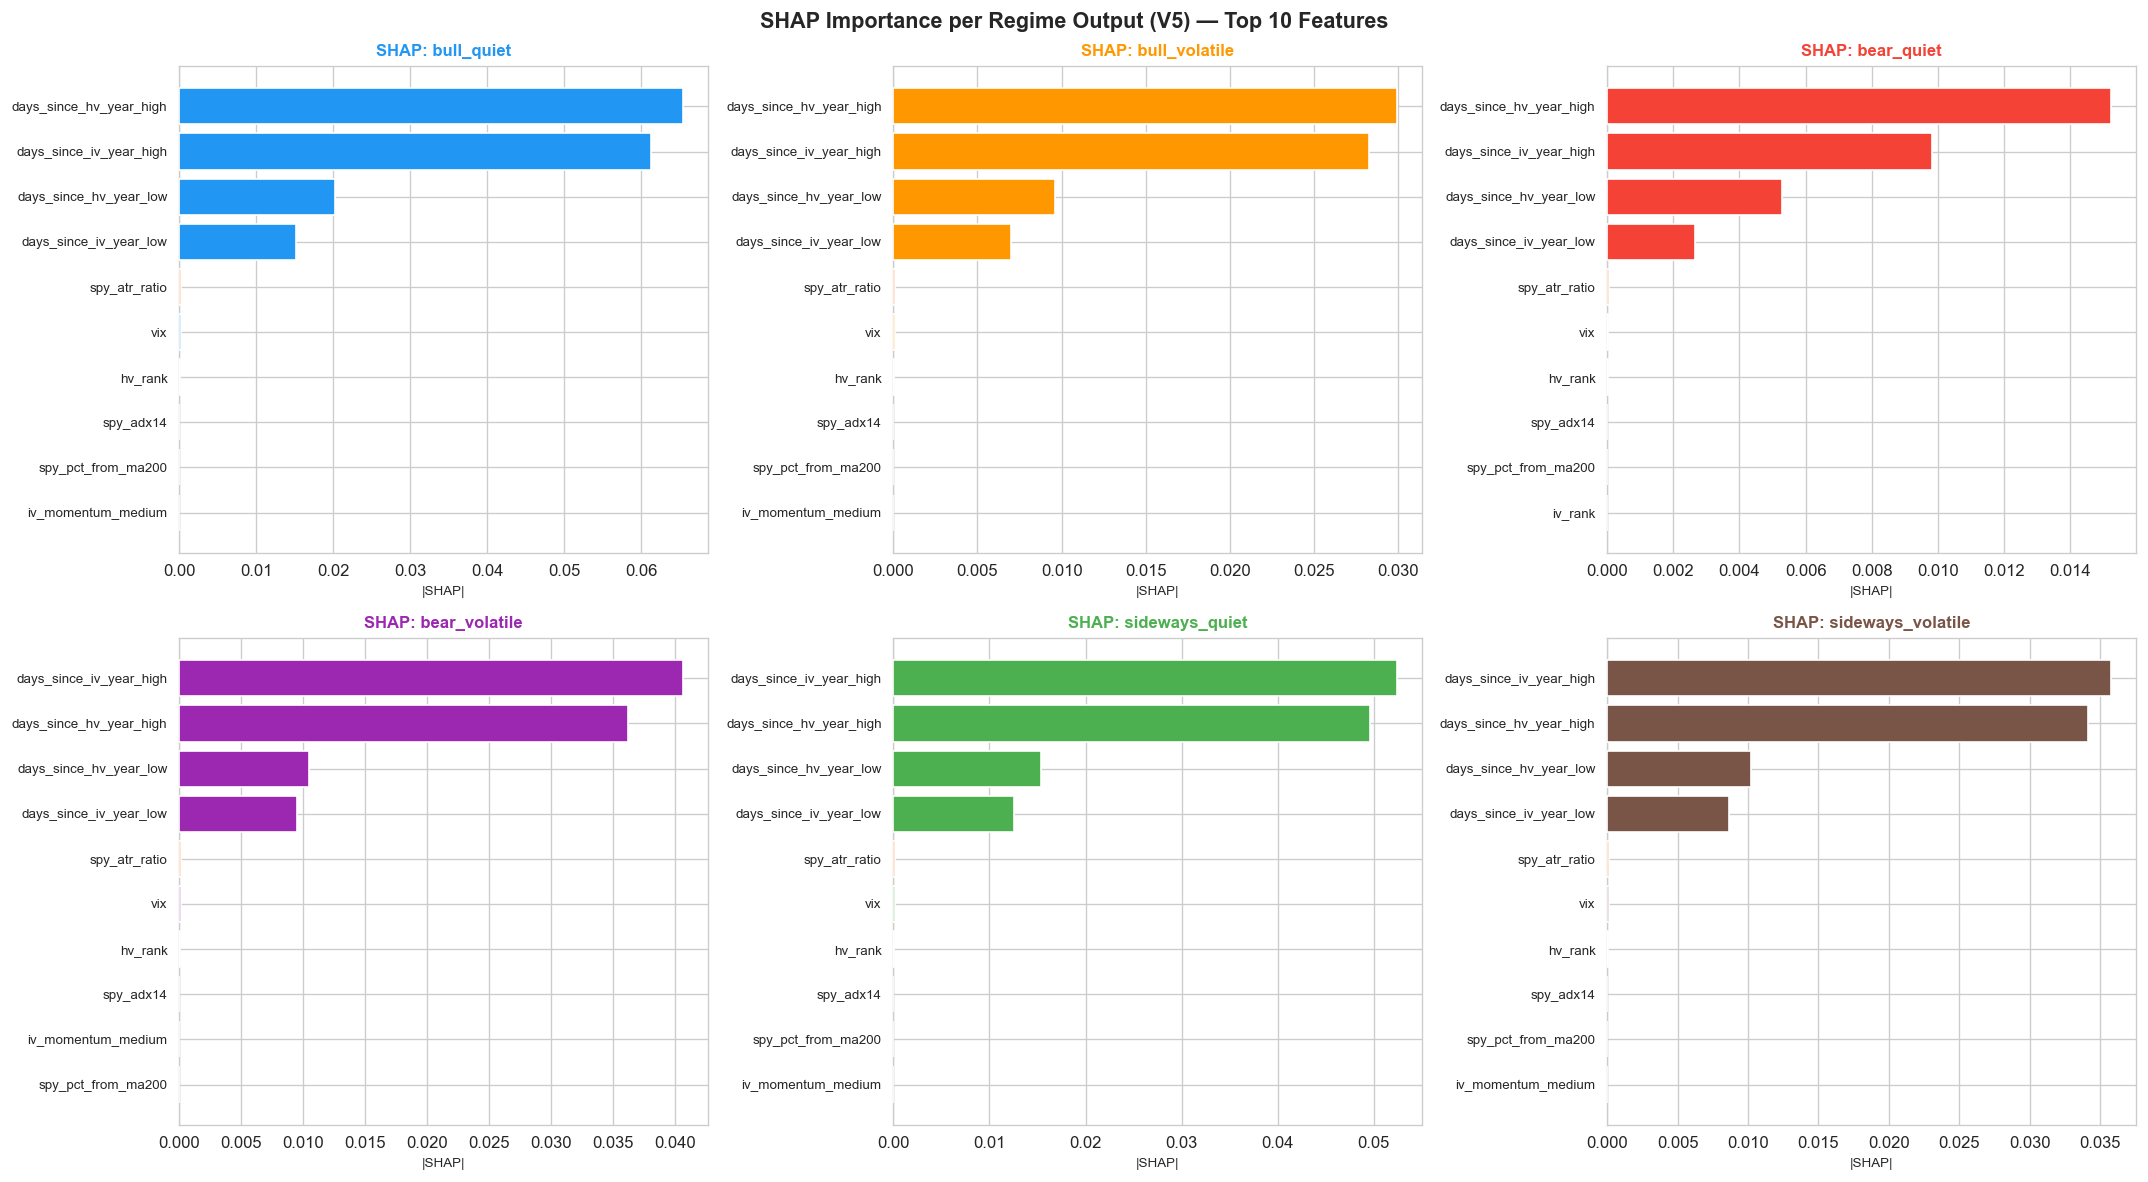

In [31]:
# new_v5 is defined in section 8; redefine as fallback
if 'new_v5' not in dir():
    new_v5 = {'spy_pct_from_ma200', 'spy_adx14', 'spy_atr_ratio'}

regime_shap_dir = V5_DIR / 'explain_regimes'
if regime_shap_dir.exists():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for k, (name, ax) in enumerate(zip(REGIME_NAMES, axes.flat)):
        shap_k_path = regime_shap_dir / f'regime_{k}/shap_importance.json'
        if not shap_k_path.exists():
            ax.set_title(f'SHAP: {name} (missing)')
            continue
        shap_k = json.load(open(shap_k_path))
        feats = list(shap_k.keys())
        vals  = list(shap_k.values())
        order = np.argsort(vals)[::-1][:10]
        f_sorted = [feats[i] for i in order]
        v_sorted = [vals[i]  for i in order]
        colors_k = ['#FF6F00' if f in new_v5 else REGIME_COLORS[k] for f in f_sorted]
        ax.barh(range(len(f_sorted))[::-1], v_sorted, color=colors_k, zorder=3)
        ax.set_yticks(range(len(f_sorted))[::-1])
        ax.set_yticklabels(f_sorted, fontsize=8)
        ax.set_title(f'SHAP: {name}', fontsize=10, fontweight='bold', color=REGIME_COLORS[k])
        ax.set_xlabel('|SHAP|', fontsize=8)

    plt.suptitle('SHAP Importance per Regime Output (V5) — Top 10 Features', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f'Per-regime SHAP directory not found at {regime_shap_dir}')

---
## 10. Explainability: IV Surface Attribution (V4 vs V5)

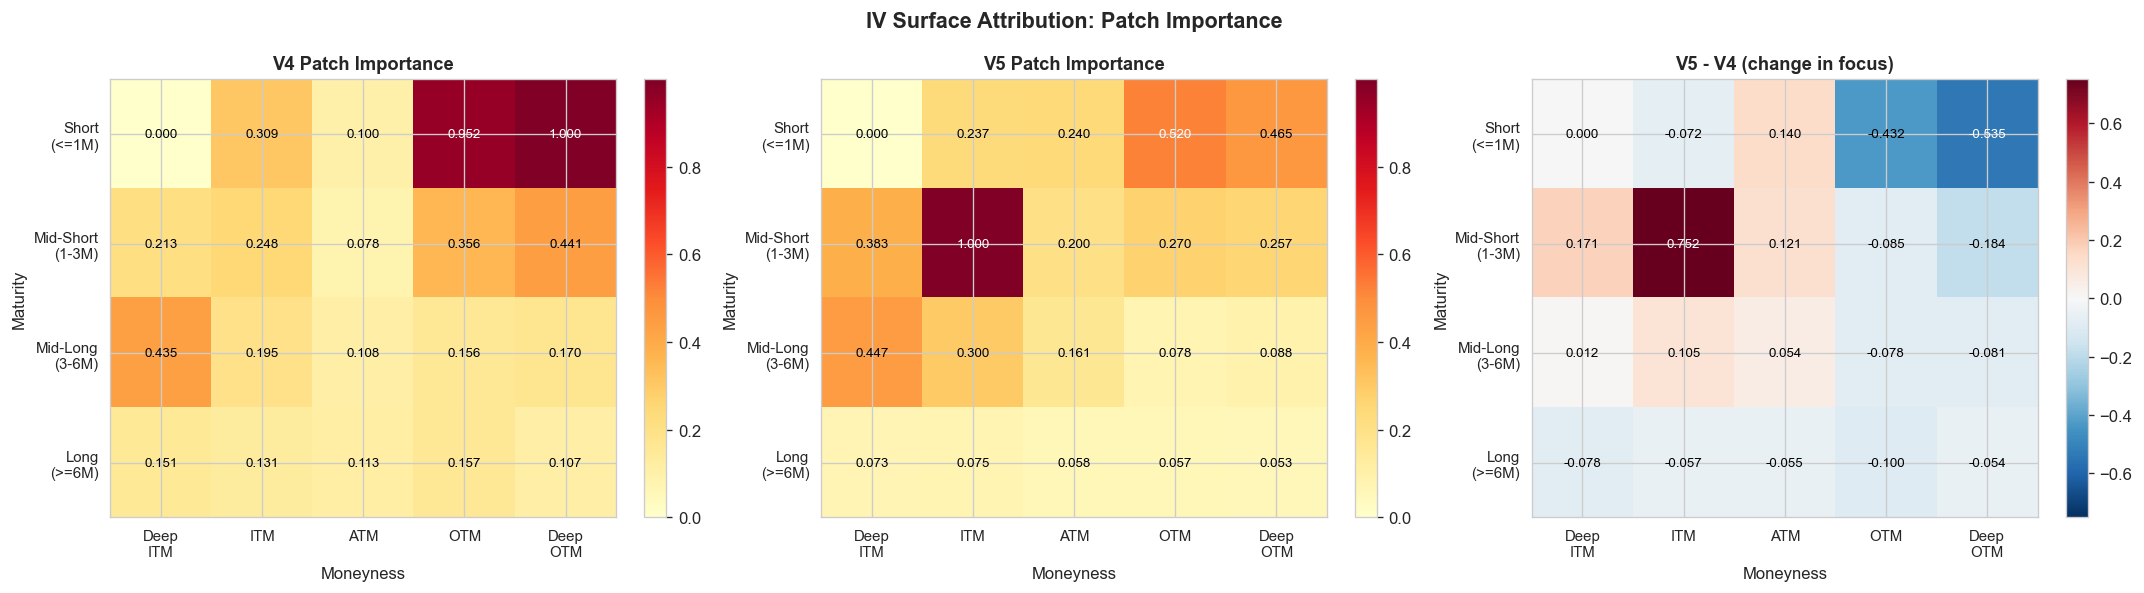

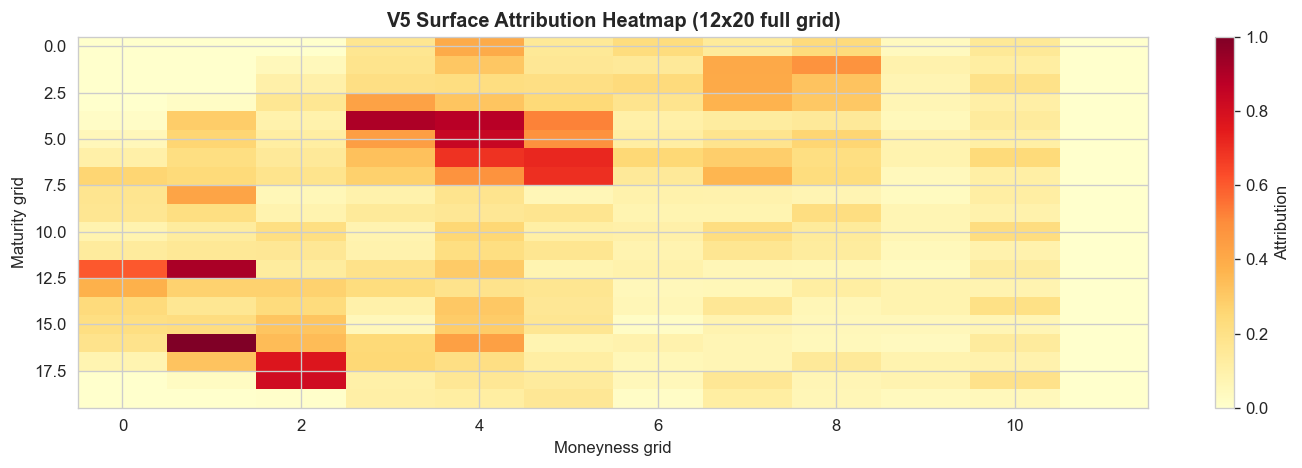

In [32]:
patch5_path   = EXP5 / 'patch_importance.npy'
patch4_path   = V4_DIR / 'explain/patch_importance.npy'
heatmap5_path = EXP5 / 'surface_heatmap.npy'

if patch5_path.exists() and patch4_path.exists():
    patches5 = np.load(patch5_path)
    patches4 = np.load(patch4_path)
    diff = patches5 - patches4

    mat_labels = ['Short\n(<=1M)', 'Mid-Short\n(1-3M)', 'Mid-Long\n(3-6M)', 'Long\n(>=6M)']
    mon_labels = ['Deep\nITM', 'ITM', 'ATM', 'OTM', 'Deep\nOTM']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, data, title in zip(
        axes,
        [patches4, patches5, diff],
        ['V4 Patch Importance', 'V5 Patch Importance', 'V5 - V4 (change in focus)']
    ):
        cmap = 'RdBu_r' if 'change' in title.lower() else 'YlOrRd'
        vmax_val = max(abs(data.max()), abs(data.min())) if 'change' in title.lower() else None
        vmin_val = -vmax_val if vmax_val is not None else None
        im = ax.imshow(data, cmap=cmap, aspect='auto', vmin=vmin_val, vmax=vmax_val)
        plt.colorbar(im, ax=ax, fraction=0.046)
        if data.shape[1] == 5:
            ax.set_xticks(range(5))
            ax.set_xticklabels(mon_labels, fontsize=9)
        if data.shape[0] == 4:
            ax.set_yticks(range(4))
            ax.set_yticklabels(mat_labels, fontsize=9)
        ax.set_xlabel('Moneyness', fontsize=10)
        ax.set_ylabel('Maturity', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                ax.text(j, i, f'{data[i,j]:.3f}', ha='center', va='center', fontsize=8,
                        color='white' if abs(data[i,j]) > 0.5 else 'black')

    plt.suptitle('IV Surface Attribution: Patch Importance', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

if heatmap5_path.exists():
    heatmap5 = np.load(heatmap5_path)
    fig, ax = plt.subplots(figsize=(12, 4))
    im = ax.imshow(heatmap5.T, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, ax=ax, label='Attribution')
    ax.set_xlabel('Moneyness grid', fontsize=10)
    ax.set_ylabel('Maturity grid', fontsize=10)
    ax.set_title('V5 Surface Attribution Heatmap (12x20 full grid)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 11. Explainability: MoE Gating Weight Analysis

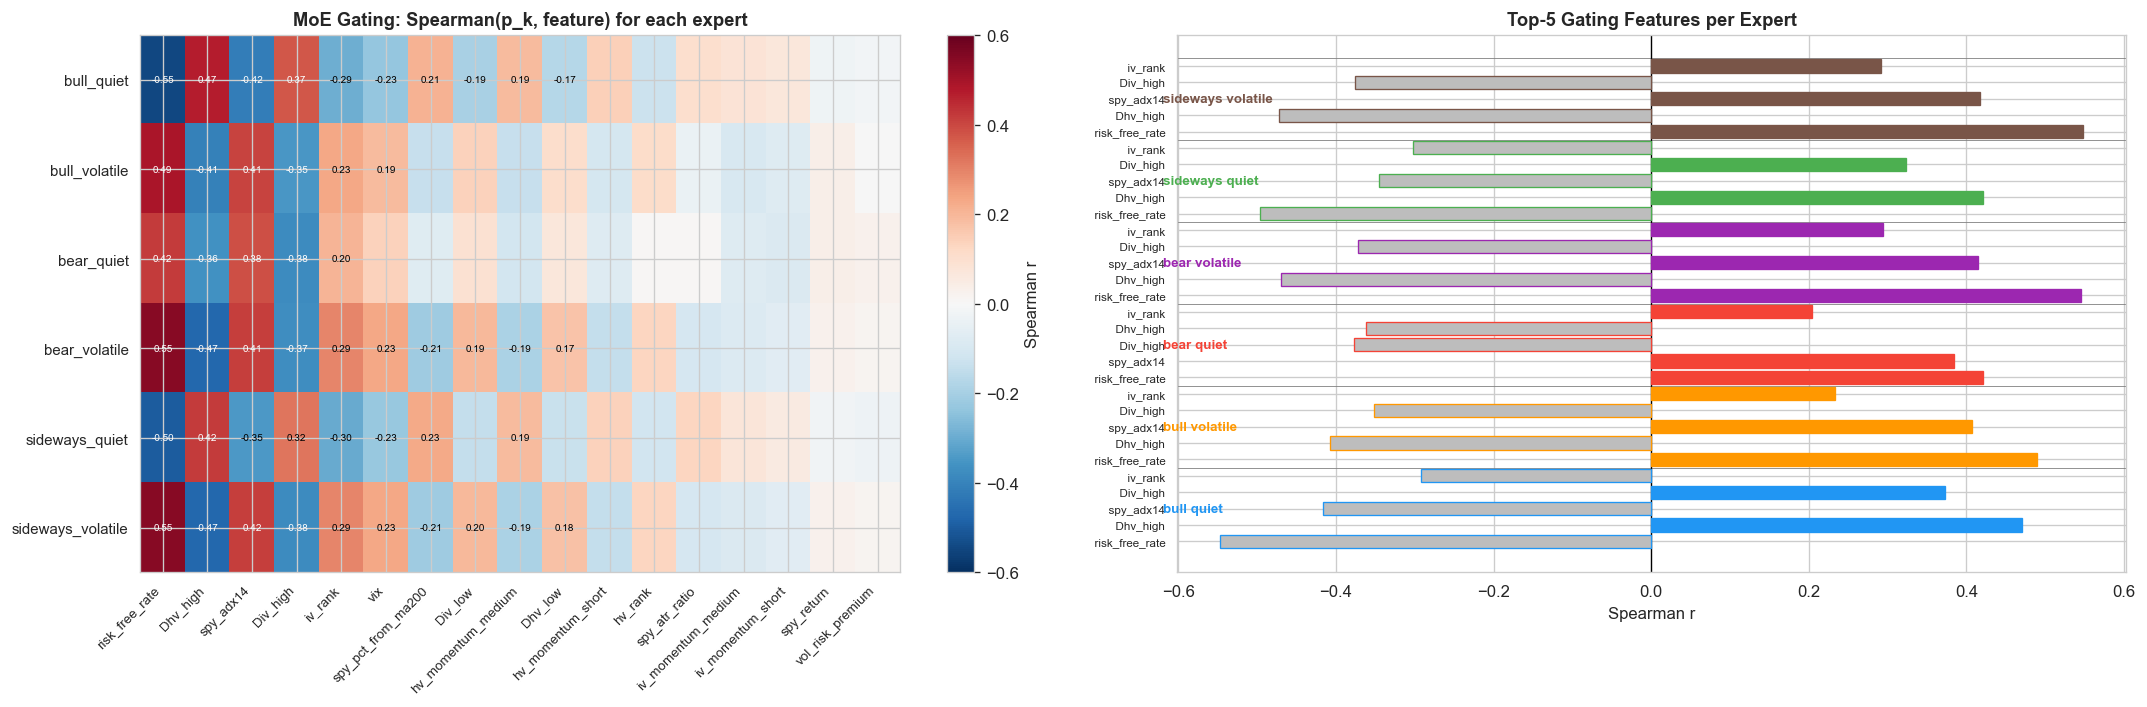

In [33]:
gating_path = EXP5 / 'gating_correlations.json'
if gating_path.exists():
    gating = json.load(open(gating_path))

    all_feat = list(gating[REGIME_NAMES[0]].keys())
    corr_mat = np.array([[gating[r].get(f, 0.0) for f in all_feat] for r in REGIME_NAMES])

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    ax = axes[0]
    im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-0.6, vmax=0.6, aspect='auto')
    plt.colorbar(im, ax=ax, label='Spearman r')
    ax.set_xticks(range(len(all_feat)))
    ax.set_xticklabels([f.replace('days_since_','D').replace('_year_','_') for f in all_feat],
                       rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(6))
    ax.set_yticklabels(REGIME_NAMES, fontsize=9)
    ax.set_title('MoE Gating: Spearman(p_k, feature) for each expert', fontsize=11, fontweight='bold')
    for i in range(6):
        for j in range(len(all_feat)):
            v = corr_mat[i, j]
            if abs(v) > 0.15:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                        color='white' if abs(v) > 0.35 else 'black')

    ax2 = axes[1]
    top_k = 5
    y_offset = 0
    yticks, ytick_labels = [], []
    for k, (name, color) in enumerate(zip(REGIME_NAMES, REGIME_COLORS)):
        row = corr_mat[k]
        top_idx = np.argsort(np.abs(row))[::-1][:top_k]
        for rank, fi in enumerate(top_idx):
            ax2.barh(y_offset, row[fi], color=color if row[fi] > 0 else '#BDBDBD',
                     edgecolor=color, linewidth=0.8, zorder=3)
            yticks.append(y_offset)
            ytick_labels.append(f'  {all_feat[fi].replace("days_since_","D").replace("_year_","_")}')
            y_offset += 1
        ax2.axhline(y_offset - 0.5, color='gray', lw=0.5)
        ax2.text(-0.62, y_offset - top_k/2 - 0.5, name.replace('_',' '), fontsize=8,
                 color=color, fontweight='bold', va='center')

    ax2.set_yticks(yticks)
    ax2.set_yticklabels(ytick_labels, fontsize=7)
    ax2.axvline(0, color='black', lw=0.8)
    ax2.set_xlabel('Spearman r', fontsize=10)
    ax2.set_title('Top-5 Gating Features per Expert', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print(f'gating_correlations.json not found at {gating_path}')

---
## 12. Explainability: Gating Active vs Inactive Feature Means

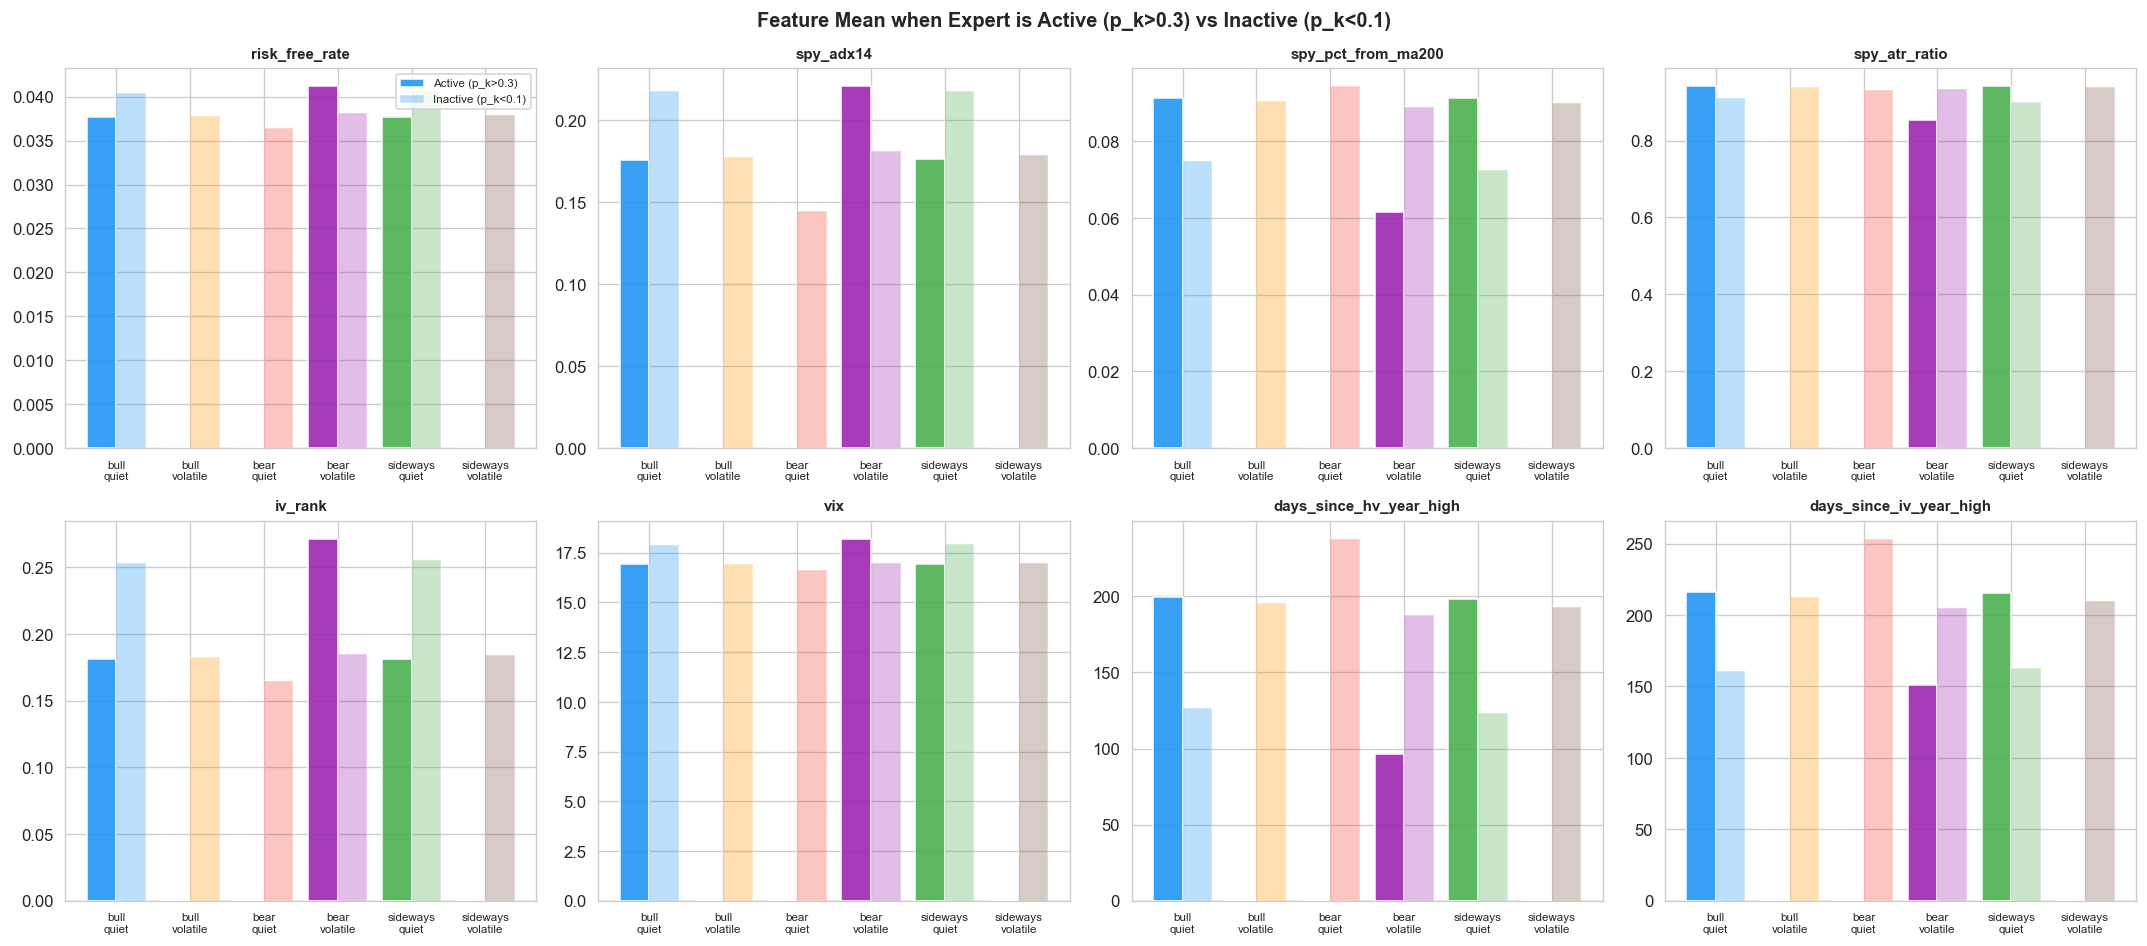

In [34]:
gfm_path = EXP5 / 'gating_feature_means.csv'
if gfm_path.exists():
    gfm = pd.read_csv(gfm_path)

    key_features = ['risk_free_rate', 'spy_adx14', 'spy_pct_from_ma200', 'spy_atr_ratio',
                    'iv_rank', 'vix', 'days_since_hv_year_high', 'days_since_iv_year_high']
    key_features = [f for f in key_features if f in gfm['feature'].values]

    if key_features:
        fig, axes = plt.subplots(2, 4, figsize=(18, 8))

        for ax, feat in zip(axes.flat, key_features):
            rows = gfm[gfm['feature'] == feat]
            regimes_short = [r.replace('_','\n') for r in REGIME_NAMES]

            active_vals   = []
            inactive_vals = []
            for r in REGIME_NAMES:
                r_rows = rows[rows['regime'] == r]
                if len(r_rows) > 0:
                    a_val = r_rows['mean_active'].values[0]
                    i_val = r_rows['mean_inactive'].values[0]
                    # Handle NaN values gracefully
                    active_vals.append(float(a_val) if pd.notna(a_val) else 0.0)
                    inactive_vals.append(float(i_val) if pd.notna(i_val) else 0.0)
                else:
                    active_vals.append(0.0)
                    inactive_vals.append(0.0)

            x = np.arange(6)
            ax.bar(x - 0.2, active_vals,   0.4, label='Active (p_k>0.3)',  color=REGIME_COLORS, alpha=0.9, zorder=3)
            ax.bar(x + 0.2, inactive_vals, 0.4, label='Inactive (p_k<0.1)', color=REGIME_COLORS, alpha=0.3, zorder=3)
            ax.set_xticks(x)
            ax.set_xticklabels(regimes_short, fontsize=7)
            ax.set_title(feat, fontsize=9, fontweight='bold')
            if feat == key_features[0]:
                ax.legend(fontsize=7, loc='upper right')
            ax.axhline(0, color='k', lw=0.5)

        plt.suptitle('Feature Mean when Expert is Active (p_k>0.3) vs Inactive (p_k<0.1)',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print('None of the key_features found in gating_feature_means.csv')
else:
    print(f'gating_feature_means.csv not found at {gfm_path}')

---
## 13. Portfolio: Equity Curve, Drawdown, Weight

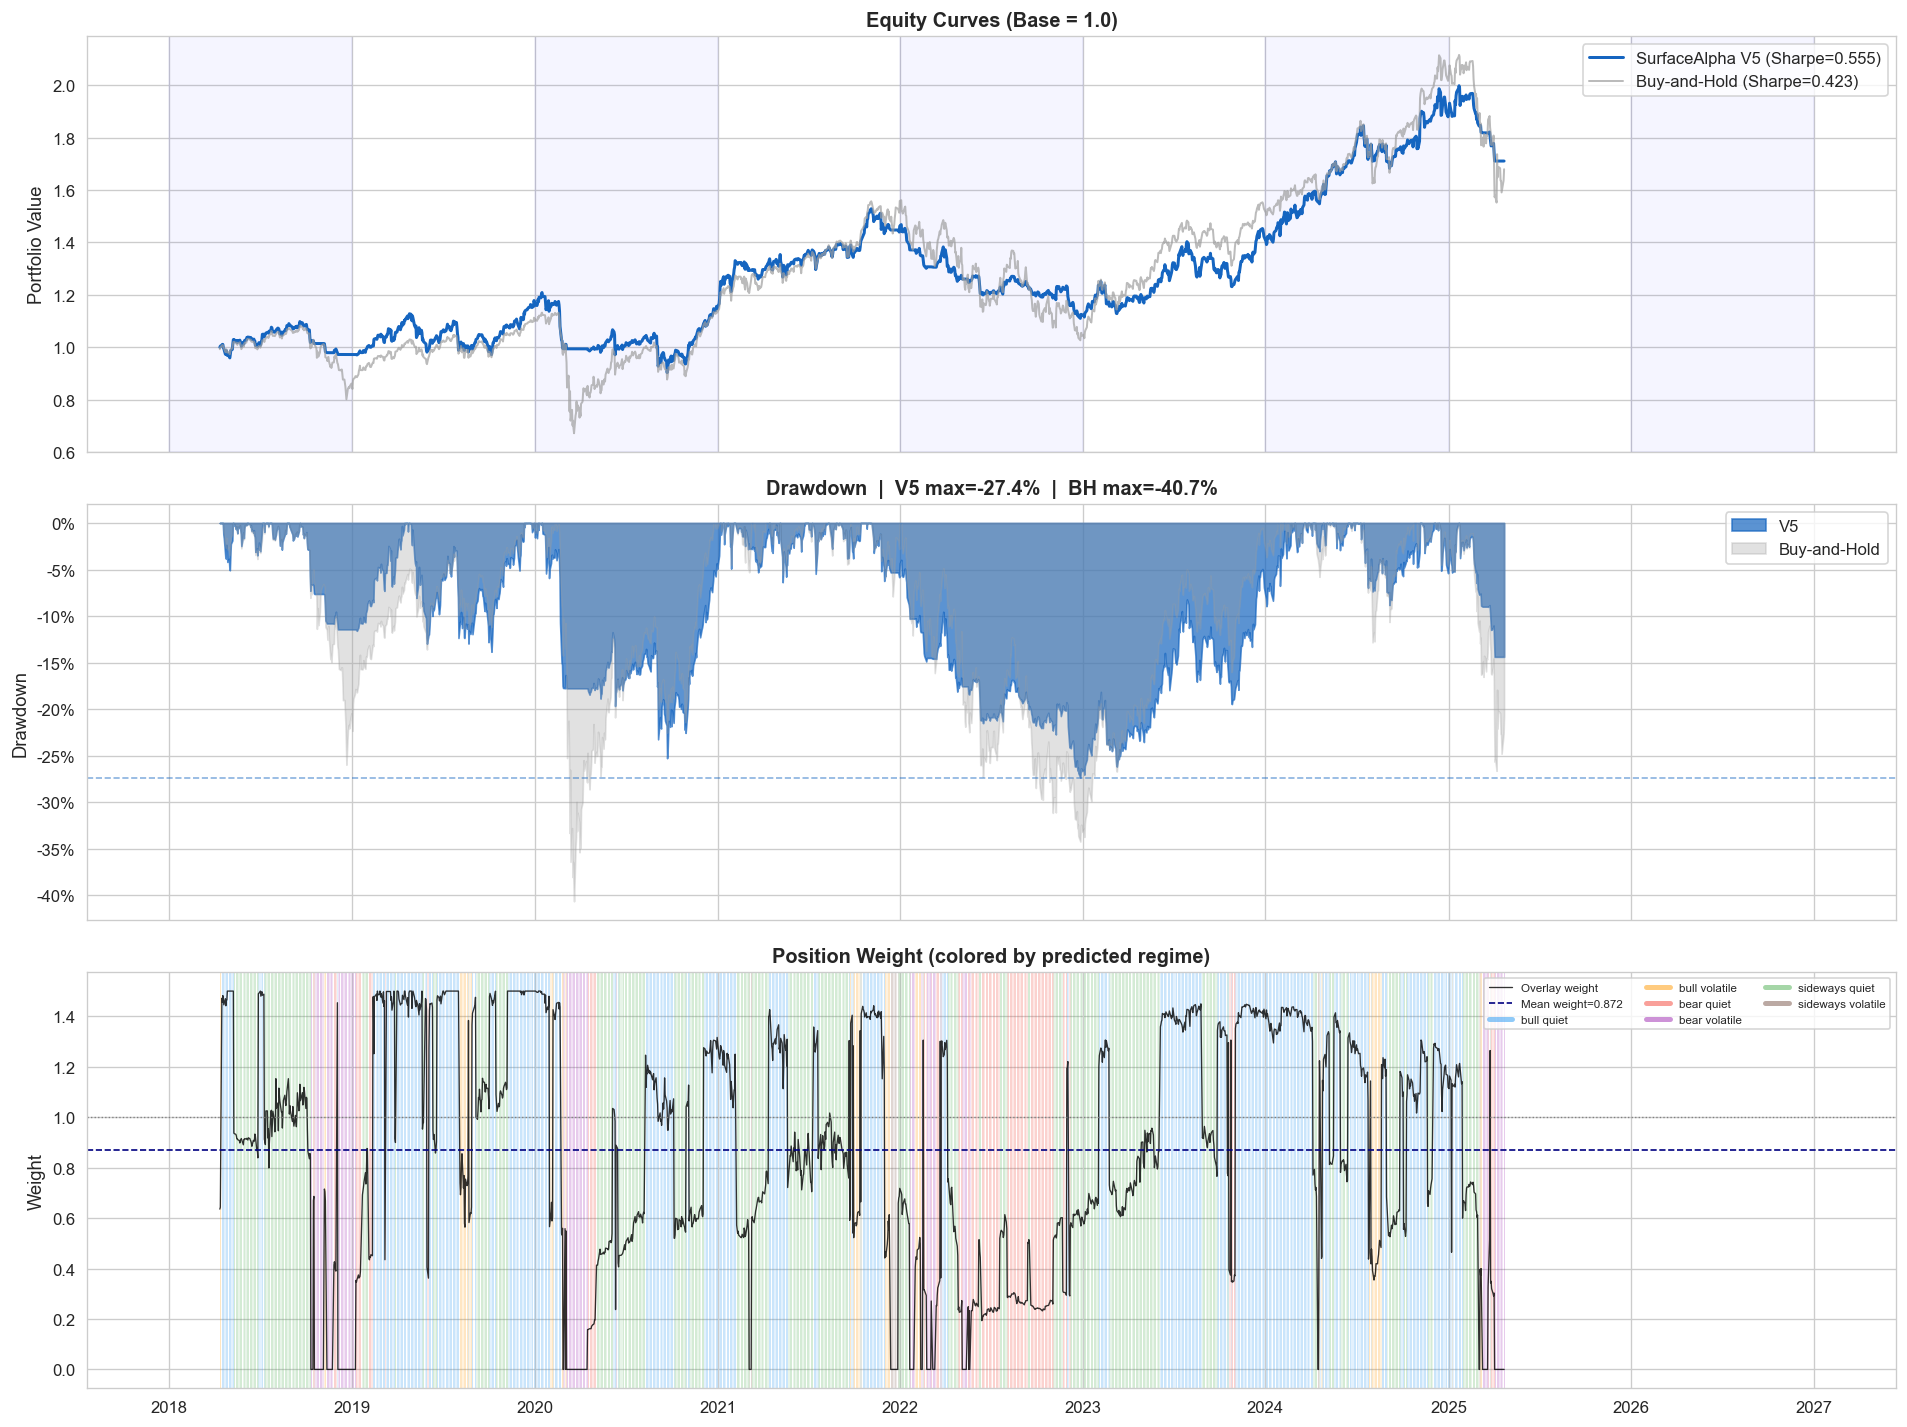

In [35]:
equity['bh_equity'] = (1 + equity['underlying_ret']).cumprod()
equity['sa_equity'] = equity['equity']
equity['sa_dd'] = equity['sa_equity'] / equity['sa_equity'].cummax() - 1
equity['bh_dd'] = equity['bh_equity'] / equity['bh_equity'].cummax() - 1

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

ax = axes[0]
ax.plot(equity['date'], equity['sa_equity'], color='#1565C0', lw=1.8,
        label=f"SurfaceAlpha V5 (Sharpe={bt5['sharpe']:.3f})")
ax.plot(equity['date'], equity['bh_equity'], color='#9E9E9E', lw=1.2, alpha=0.7,
        label=f"Buy-and-Hold (Sharpe={bmark['buy_and_hold']['sharpe']:.3f})")
ax.set_ylabel('Portfolio Value', fontsize=11)
ax.set_title('Equity Curves (Base = 1.0)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
for yr in range(2018, 2027, 2):
    ax.axvspan(pd.Timestamp(f'{yr}-01-01'), pd.Timestamp(f'{yr+1}-01-01'), alpha=0.04, color='blue')

ax2 = axes[1]
ax2.fill_between(equity['date'], equity['sa_dd'], 0, alpha=0.7, color='#1565C0', label='V5')
ax2.fill_between(equity['date'], equity['bh_dd'], 0, alpha=0.3, color='#9E9E9E', label='Buy-and-Hold')
ax2.axhline(bt5['max_drawdown_pct']/100, color='#1565C0', ls='--', lw=1, alpha=0.5)
ax2.set_ylabel('Drawdown', fontsize=11)
ax2.set_title(
    f"Drawdown  |  V5 max={bt5['max_drawdown_pct']:.1f}%  |  BH max={bmark['buy_and_hold']['max_drawdown_pct']:.1f}%",
    fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

ax3 = axes[2]
if 'regime_name' in equity.columns:
    regime_int = equity['regime_name'].map({r: k for k, r in enumerate(REGIME_NAMES)}).fillna(0)
    for idx in range(len(equity)):
        k = int(regime_int.iloc[idx])
        ax3.axvline(equity['date'].iloc[idx], color=REGIME_COLORS[k], lw=0.5, alpha=0.15)
if 'weight' in equity.columns:
    ax3.plot(equity['date'], equity['weight'], color='black', lw=0.8, alpha=0.8, label='Overlay weight')
    ax3.axhline(bt5.get('avg_weight', 1.0), color='navy', ls='--', lw=1,
                label=f"Mean weight={bt5.get('avg_weight', 0.0):.3f}")
    ax3.axhline(1.0, color='gray', ls=':', lw=0.8)
    ax3.set_ylabel('Weight', fontsize=11)
ax3.set_title('Position Weight (colored by predicted regime)', fontsize=12, fontweight='bold')
for k, (name, color) in enumerate(zip(REGIME_NAMES, REGIME_COLORS)):
    ax3.plot([], [], color=color, lw=3, alpha=0.5, label=name.replace('_', ' '))
ax3.legend(loc='upper right', fontsize=7, ncol=3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

---
## 14. Portfolio: Yearly Calendar Returns

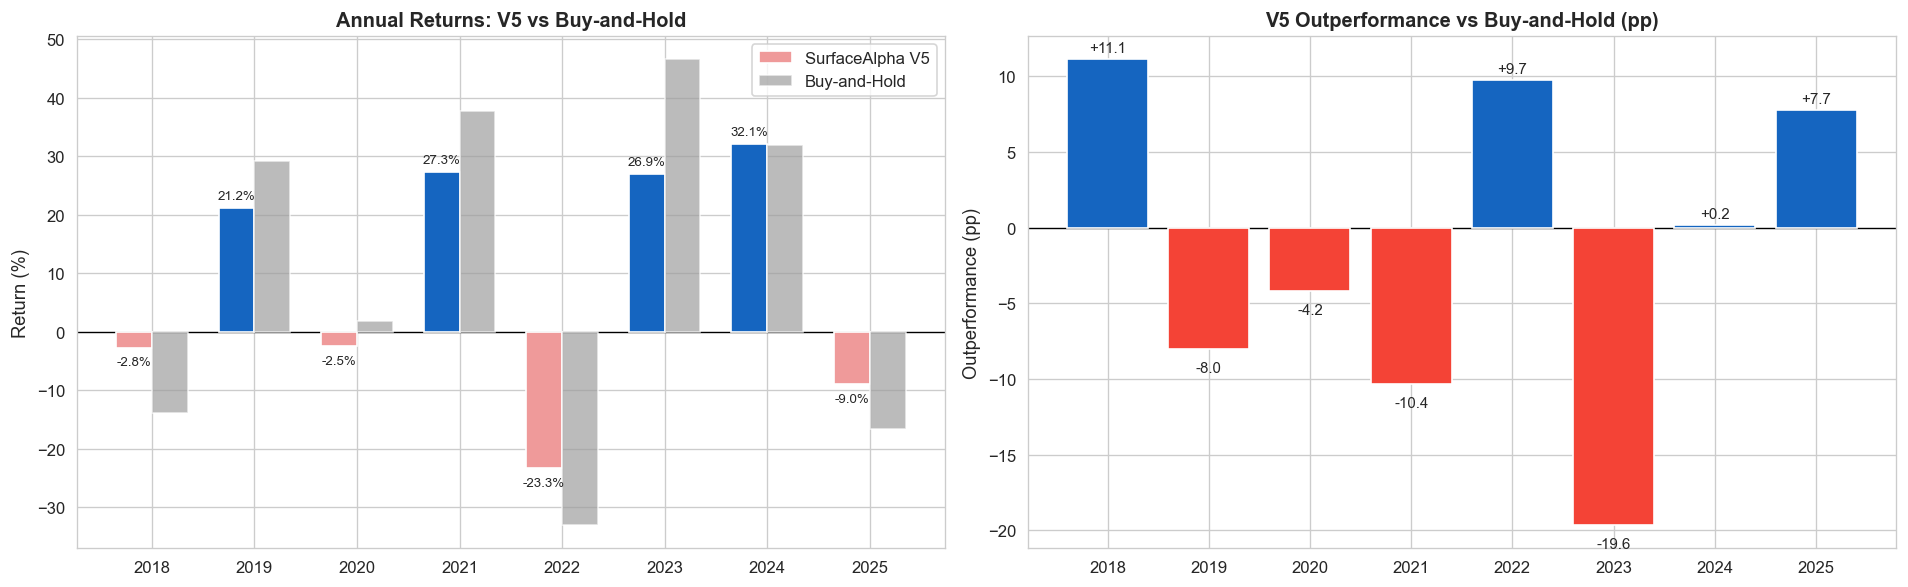

Calendar year summary:
 year  sa_pct  bh_pct  out_pp
 2018    -2.8   -13.9    11.1
 2019    21.2    29.2    -8.0
 2020    -2.5     1.7    -4.2
 2021    27.3    37.7   -10.4
 2022   -23.3   -33.1     9.7
 2023    26.9    46.5   -19.6
 2024    32.1    32.0     0.2
 2025    -9.0   -16.7     7.7


In [36]:
equity['year'] = equity['date'].dt.year
yearly_sa = equity.groupby('year').apply(lambda g: (1+g['strategy_ret']).prod()-1).reset_index()
yearly_bh = equity.groupby('year').apply(lambda g: (1+g['underlying_ret']).prod()-1).reset_index()
yearly_sa.columns = ['year','sa_ret']
yearly_bh.columns = ['year','bh_ret']
yr_df = yearly_sa.merge(yearly_bh, on='year')
yr_df['outperform'] = yr_df['sa_ret'] - yr_df['bh_ret']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
x = np.arange(len(yr_df))
w = 0.35
sa_colors = ['#1565C0' if v > 0 else '#EF9A9A' for v in yr_df['sa_ret']]
ax.bar(x - w/2, yr_df['sa_ret']*100, w, color=sa_colors, label='SurfaceAlpha V5', zorder=3)
ax.bar(x + w/2, yr_df['bh_ret']*100, w, color='#9E9E9E', alpha=0.7, label='Buy-and-Hold', zorder=3)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(yr_df['year'], fontsize=10)
ax.set_ylabel('Return (%)', fontsize=11)
ax.set_title('Annual Returns: V5 vs Buy-and-Hold', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
for i, sa in enumerate(yr_df['sa_ret']):
    ax.text(i-w/2, sa*100 + (1.5 if sa>0 else -3), f'{sa*100:.1f}%', ha='center', fontsize=8)

ax2 = axes[1]
colors_out = ['#1565C0' if v > 0 else '#F44336' for v in yr_df['outperform']]
ax2.bar(x, yr_df['outperform']*100, color=colors_out, zorder=3)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(yr_df['year'], fontsize=10)
ax2.set_ylabel('Outperformance (pp)', fontsize=11)
ax2.set_title('V5 Outperformance vs Buy-and-Hold (pp)', fontsize=12, fontweight='bold')
for i, v in enumerate(yr_df['outperform']):
    ax2.text(i, v*100 + (0.5 if v>0 else -1.5), f'{v*100:+.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Calendar year summary:')
print(yr_df.assign(
    sa_pct=lambda d: (d.sa_ret*100).round(1),
    bh_pct=lambda d: (d.bh_ret*100).round(1),
    out_pp=lambda d: (d.outperform*100).round(1)
)[['year','sa_pct','bh_pct','out_pp']].to_string(index=False))

---
## 15. Portfolio: Per-Regime Performance (V4 vs V5)

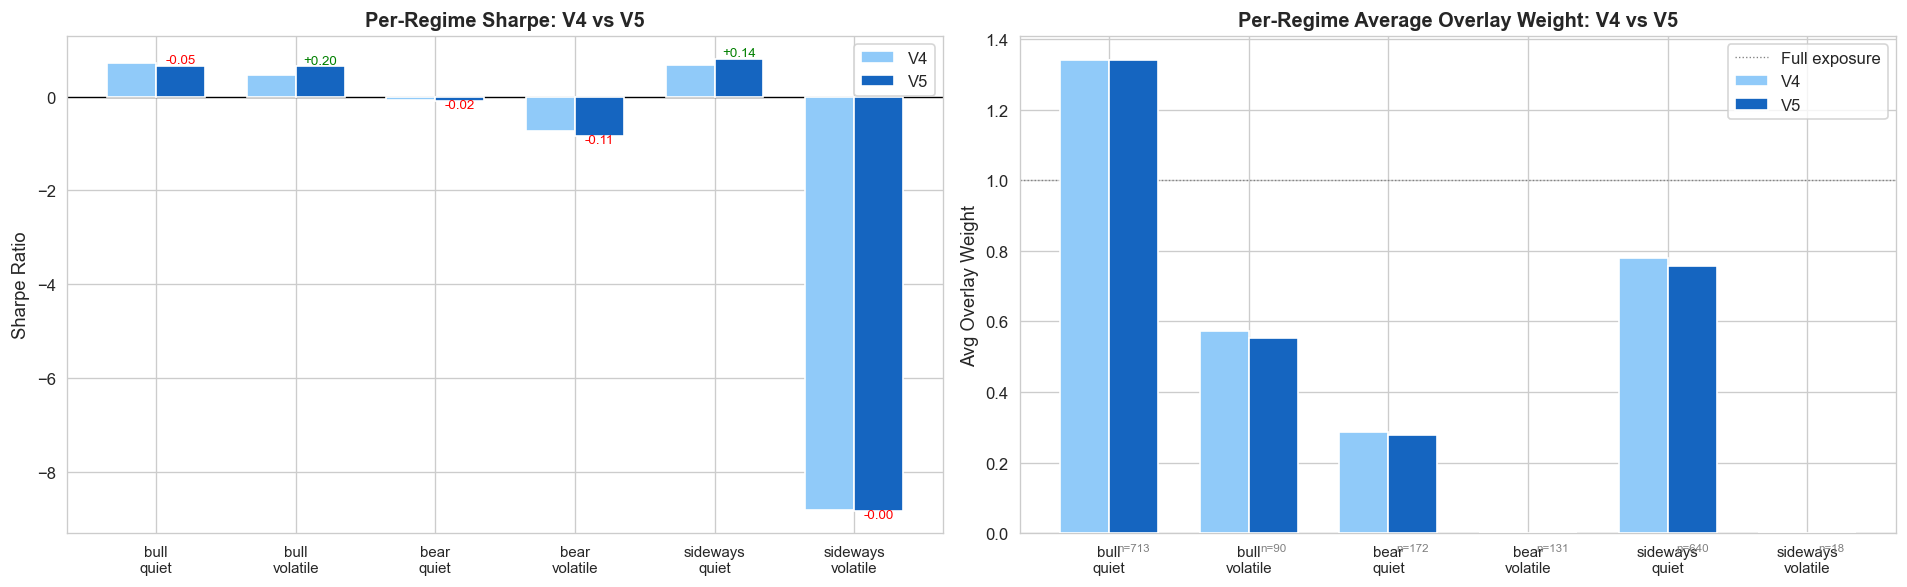

V5 vs V4 per-regime:
  bull_quiet            V4=0.705  V5=0.657  D=-0.048  worse
  bull_volatile         V4=0.451  V5=0.653  D=+0.202  better
  bear_quiet            V4=-0.068  V5=-0.085  D=-0.017  worse
  bear_volatile         V4=-0.737  V5=-0.850  D=-0.113  worse
  sideways_quiet        V4=0.667  V5=0.808  D=+0.141  better
  sideways_volatile     V4=-8.818  V5=-8.821  D=-0.003  worse


In [37]:
pr4 = bt4['per_regime']
pr5 = bt5['per_regime']

regime_data = []
for r in REGIME_NAMES:
    if r in pr4 and r in pr5:
        regime_data.append({
            'regime': r,
            'v4_sharpe': pr4[r].get('sharpe', 0),
            'v5_sharpe': pr5[r].get('sharpe', 0),
            'v4_weight': pr4[r].get('avg_weight', 0),
            'v5_weight': pr5[r].get('avg_weight', 0),
            'v5_n': pr5[r].get('n', 0),
        })
rd = pd.DataFrame(regime_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(rd))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, rd['v4_sharpe'], w, color='#90CAF9', label='V4', zorder=3)
ax.bar(x + w/2, rd['v5_sharpe'], w, color='#1565C0', label='V5', zorder=3)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([r.replace('_','\n') for r in rd['regime']], fontsize=9)
ax.set_ylabel('Sharpe Ratio', fontsize=11)
ax.set_title('Per-Regime Sharpe: V4 vs V5', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
for xi, (v4, v5) in enumerate(zip(rd['v4_sharpe'], rd['v5_sharpe'])):
    delta = v5 - v4
    ax.text(xi + w/2, v5 + (0.05 if v5 > 0 else -0.15), f'{delta:+.2f}',
            ha='center', fontsize=8, color='green' if delta > 0 else 'red')

ax2 = axes[1]
ax2.bar(x - w/2, rd['v4_weight'], w, color='#90CAF9', label='V4', zorder=3)
ax2.bar(x + w/2, rd['v5_weight'], w, color='#1565C0', label='V5', zorder=3)
ax2.axhline(1.0, color='gray', ls=':', lw=0.8, label='Full exposure')
ax2.set_xticks(x)
ax2.set_xticklabels([r.replace('_','\n') for r in rd['regime']], fontsize=9)
ax2.set_ylabel('Avg Overlay Weight', fontsize=11)
ax2.set_title('Per-Regime Average Overlay Weight: V4 vs V5', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
for xi, n in enumerate(rd['v5_n']):
    ax2.text(xi + w/2, -0.05, f'n={n}', ha='center', fontsize=7, color='gray')

plt.tight_layout()
plt.show()

print('V5 vs V4 per-regime:')
for _, row in rd.iterrows():
    delta = row['v5_sharpe'] - row['v4_sharpe']
    print(f"  {row['regime']:20s}  V4={row['v4_sharpe']:.3f}  V5={row['v5_sharpe']:.3f}  D={delta:+.3f}  {'better' if delta > 0 else 'worse'}")

---
## 16. Portfolio: Benchmark Comparison

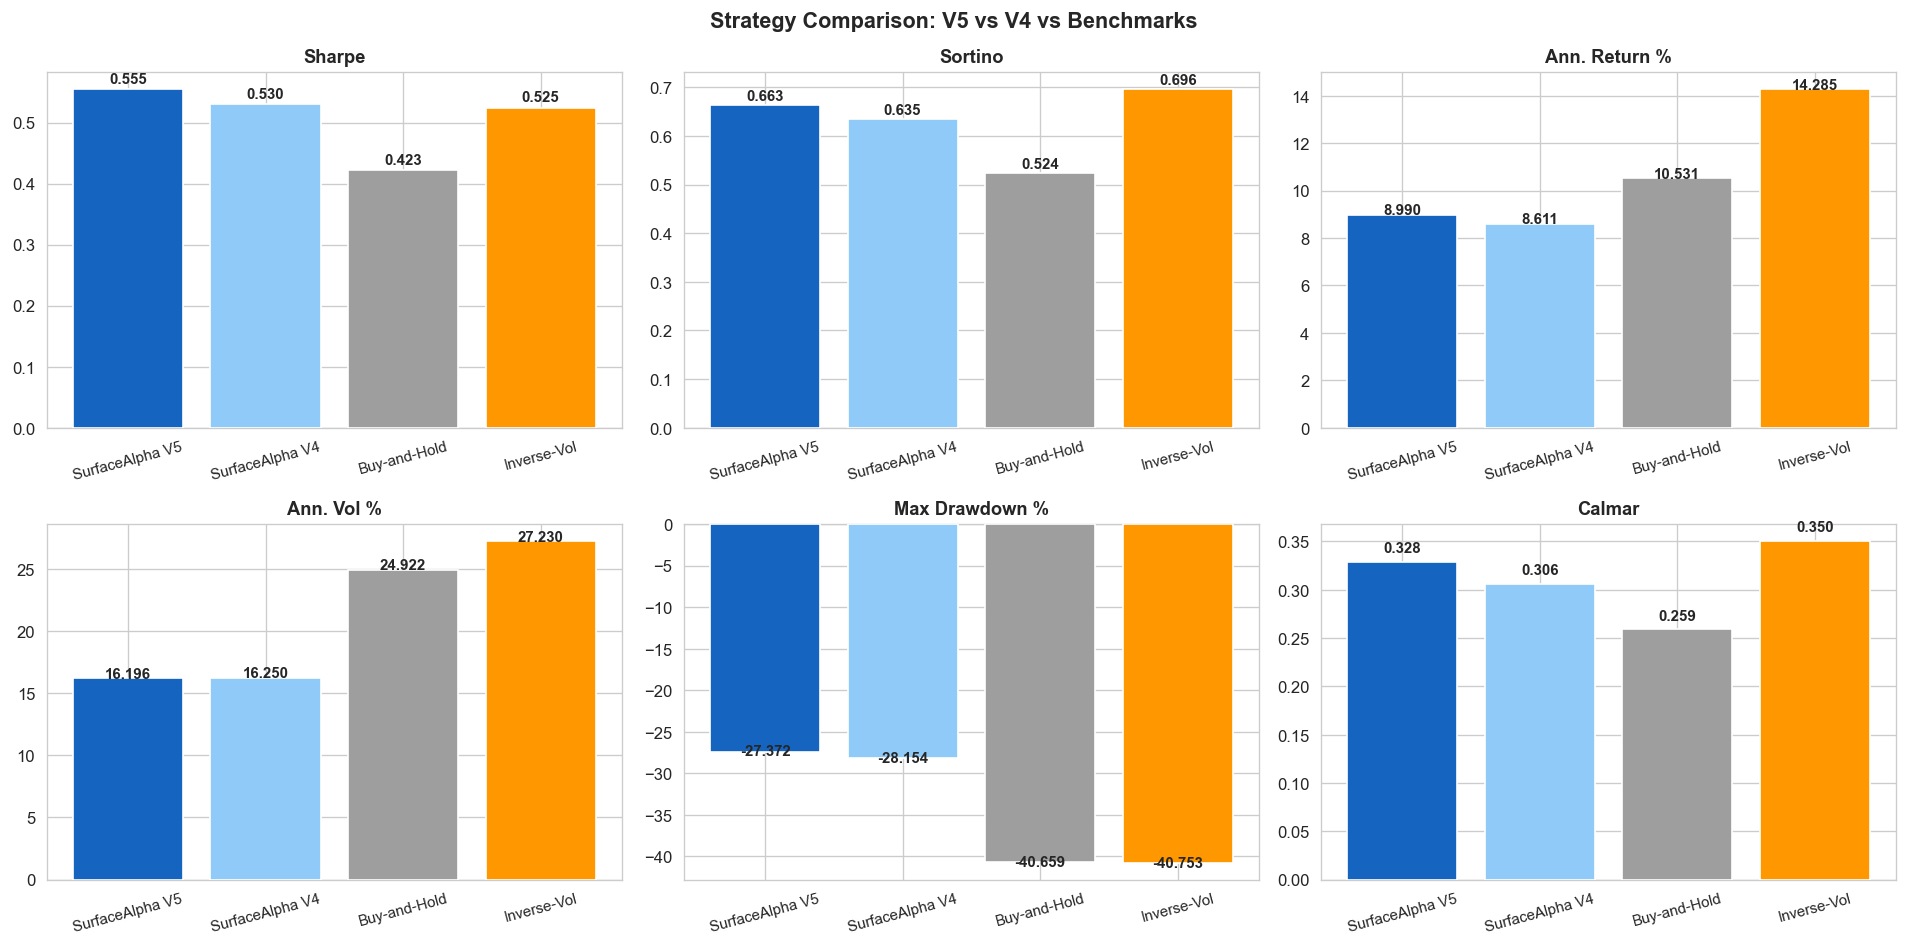

                 Sharpe  Sortino  Ann. Return %  Ann. Vol %  Max Drawdown %  Calmar
SurfaceAlpha V5  0.5550   0.6635          8.990      16.196         -27.372  0.3284
SurfaceAlpha V4  0.5299   0.6353          8.611      16.250         -28.154  0.3058
Buy-and-Hold     0.4226   0.5242         10.531      24.922         -40.659  0.2590
Inverse-Vol      0.5246   0.6964         14.285      27.230         -40.753  0.3505


In [38]:
strategies = {
    'SurfaceAlpha V5': bt5,
    'SurfaceAlpha V4': bt4,
    'Buy-and-Hold': bmark['buy_and_hold'],
    'Inverse-Vol': bmark.get('inverse_vol', {}),
}

metrics = ['sharpe','sortino','ann_return_pct','ann_vol_pct','max_drawdown_pct','calmar']
labels  = ['Sharpe','Sortino','Ann. Return %','Ann. Vol %','Max Drawdown %','Calmar']
colors_strat = ['#1565C0','#90CAF9','#9E9E9E','#FF9800']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, m, lbl in zip(axes.flat, metrics, labels):
    vals = [strategies[s].get(m, np.nan) for s in strategies]
    bars = ax.bar(list(strategies.keys()), vals, color=colors_strat, zorder=3)
    ax.set_title(lbl, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15, labelsize=9)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height() + (0.01 if val >= 0 else -0.5),
                    f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.axhline(0, color='k', lw=0.5)

plt.suptitle('Strategy Comparison: V5 vs V4 vs Benchmarks', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

comp = pd.DataFrame({s: {m: strategies[s].get(m, np.nan) for m in metrics}
                     for s in strategies}).T
comp.columns = labels
print(comp.round(4).to_string())

---
## 17. Portfolio: Rolling Performance

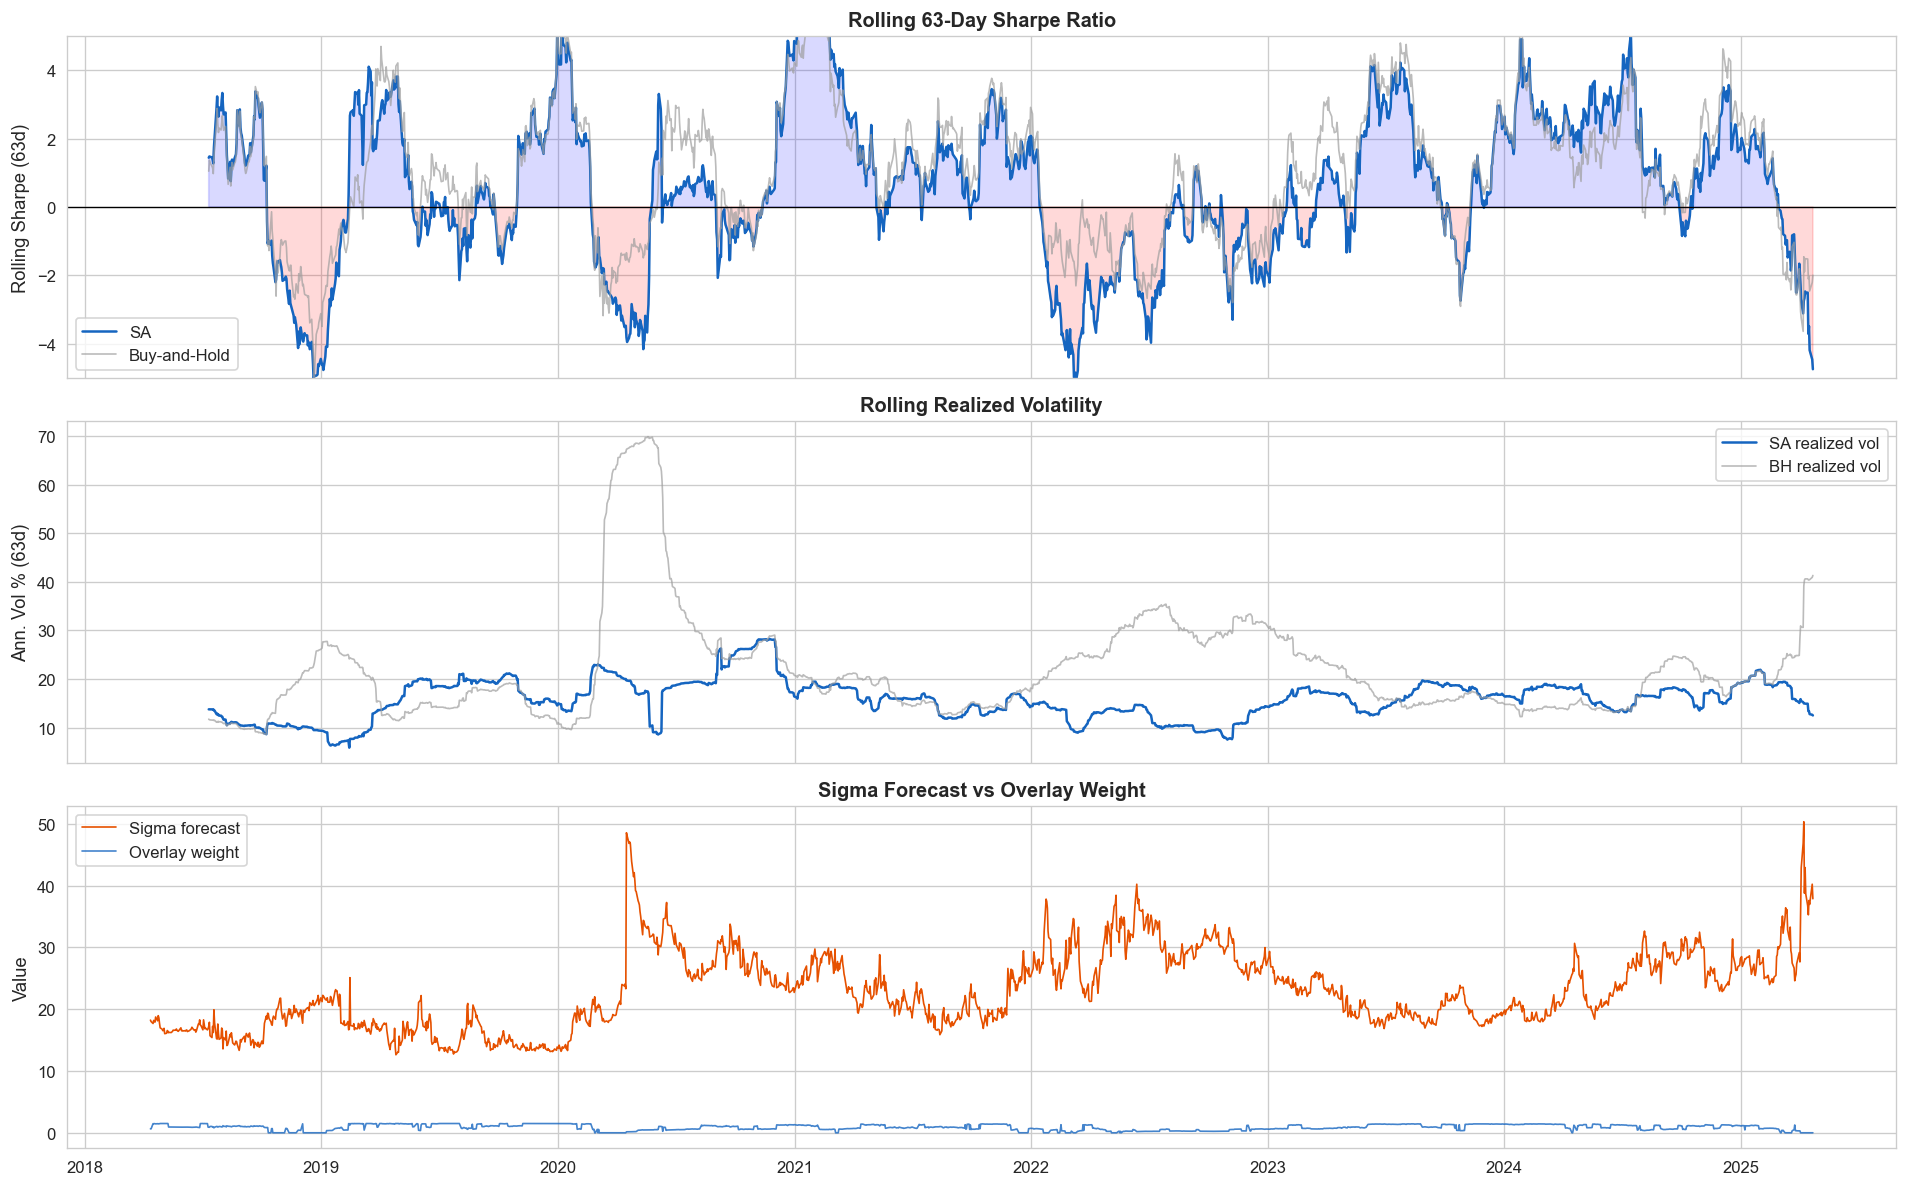

In [43]:
equity_sorted = equity.sort_values('date').copy()

def rolling_sharpe(returns, window=63):
    roll_mean = returns.rolling(window).mean()
    roll_std  = returns.rolling(window).std()
    return (roll_mean / roll_std.clip(lower=1e-8)) * np.sqrt(252)

equity_sorted['roll_sharpe_sa'] = rolling_sharpe(equity_sorted['strategy_ret'])
equity_sorted['roll_sharpe_bh'] = rolling_sharpe(equity_sorted['underlying_ret'])
equity_sorted['roll_vol_sa'] = equity_sorted['strategy_ret'].rolling(63).std() * np.sqrt(252) * 100
equity_sorted['roll_vol_bh'] = equity_sorted['underlying_ret'].rolling(63).std() * np.sqrt(252) * 100

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

ax = axes[0]
ax.plot(equity_sorted['date'], equity_sorted['roll_sharpe_sa'], color='#1565C0', lw=1.5, label='SA')
ax.plot(equity_sorted['date'], equity_sorted['roll_sharpe_bh'], color='#9E9E9E', lw=1, alpha=0.7, label='Buy-and-Hold')
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(equity_sorted['date'], equity_sorted['roll_sharpe_sa'], 0,
                where=equity_sorted['roll_sharpe_sa'] > 0, alpha=0.15, color='blue')
ax.fill_between(equity_sorted['date'], equity_sorted['roll_sharpe_sa'], 0,
                where=equity_sorted['roll_sharpe_sa'] < 0, alpha=0.15, color='red')
ax.set_ylabel('Rolling Sharpe (63d)', fontsize=11)
ax.set_title('Rolling 63-Day Sharpe Ratio', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-5, 5)

ax2 = axes[1]
ax2.plot(equity_sorted['date'], equity_sorted['roll_vol_sa'], color='#1565C0', lw=1.5, label='SA realized vol')
ax2.plot(equity_sorted['date'], equity_sorted['roll_vol_bh'], color='#9E9E9E', lw=1, alpha=0.7, label='BH realized vol')
ax2.set_ylabel('Ann. Vol % (63d)', fontsize=11)
ax2.set_title('Rolling Realized Volatility', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

ax3 = axes[2]
if 'sigma_hat' in equity_sorted.columns:
    ax3.plot(equity_sorted['date'], equity_sorted['sigma_hat']*100, color='#E65100', lw=1, label='Sigma forecast')
if 'weight' in equity_sorted.columns:
    ax3.plot(equity_sorted['date'], equity_sorted['weight'], color='#1565C0', lw=1, alpha=0.8, label='Overlay weight')
ax3.set_ylabel('Value', fontsize=11)
ax3.set_title('Sigma Forecast vs Overlay Weight', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

---
## 18. Tail Risk Detection

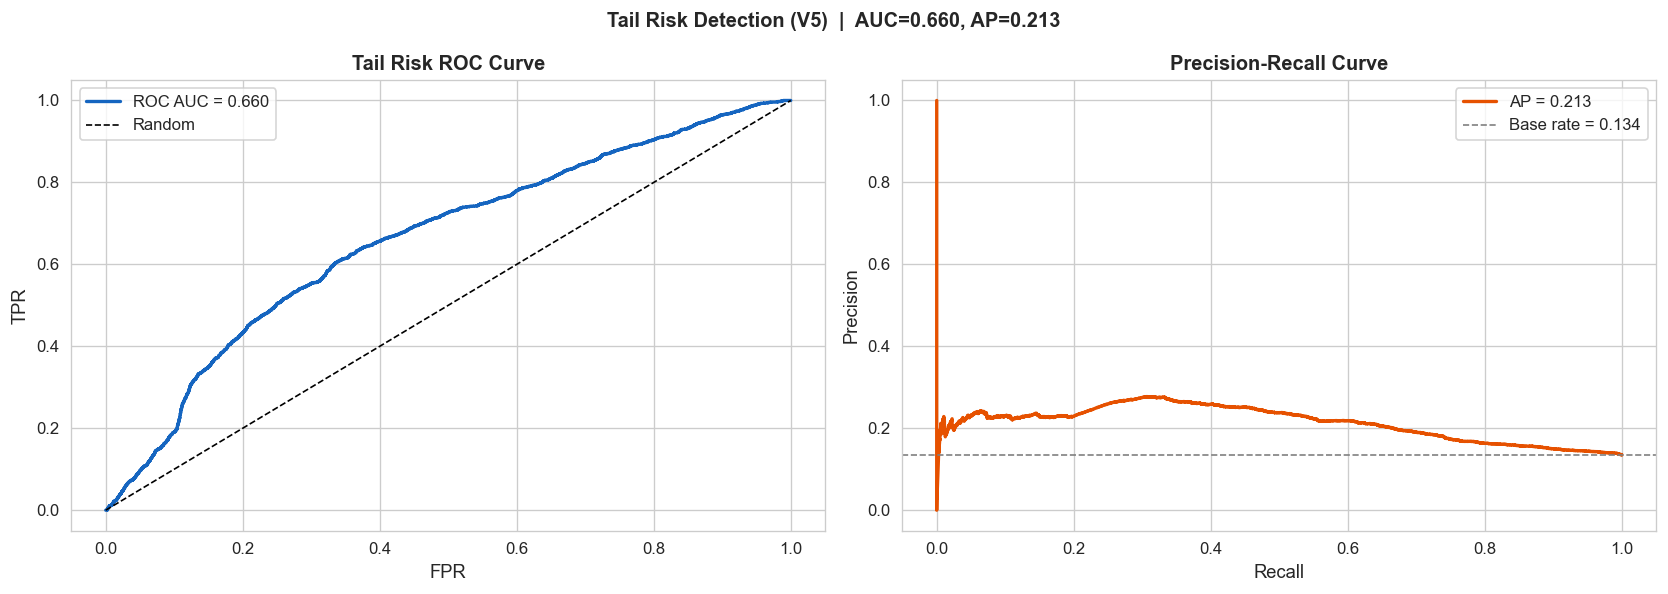

Tail AUC: V4=0.5377  V5=0.5598


In [44]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

mask_valid = preds['tail_prob'].notna() & preds['target_tail'].notna()
if mask_valid.sum() > 100:
    y_true  = preds.loc[mask_valid, 'target_tail'].astype(int).values
    y_score = preds.loc[mask_valid, 'tail_prob'].values

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc     = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap        = average_precision_score(y_true, y_score)
    base_rate = y_true.mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(fpr, tpr, color='#1565C0', lw=2, label=f'ROC AUC = {roc_auc:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1, label='Random')
    ax.set_xlabel('FPR', fontsize=11)
    ax.set_ylabel('TPR', fontsize=11)
    ax.set_title('Tail Risk ROC Curve', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)

    ax2 = axes[1]
    ax2.plot(recall, precision, color='#E65100', lw=2, label=f'AP = {ap:.3f}')
    ax2.axhline(base_rate, color='gray', ls='--', lw=1, label=f'Base rate = {base_rate:.3f}')
    ax2.set_xlabel('Recall', fontsize=11)
    ax2.set_ylabel('Precision', fontsize=11)
    ax2.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)

    plt.suptitle(f'Tail Risk Detection (V5)  |  AUC={roc_auc:.3f}, AP={ap:.3f}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Tail AUC: V4={eval4["aggregate"]["clf_tail_auc"]["mean"]:.4f}  V5={eval5["aggregate"]["clf_tail_auc"]["mean"]:.4f}')
else:
    print('Insufficient valid tail_prob values for ROC analysis.')
    print(f'V5 tail AUC (from eval report): {eval5["aggregate"]["clf_tail_auc"]["mean"]:.4f}')

---
## 19. Regime Feature Fingerprints

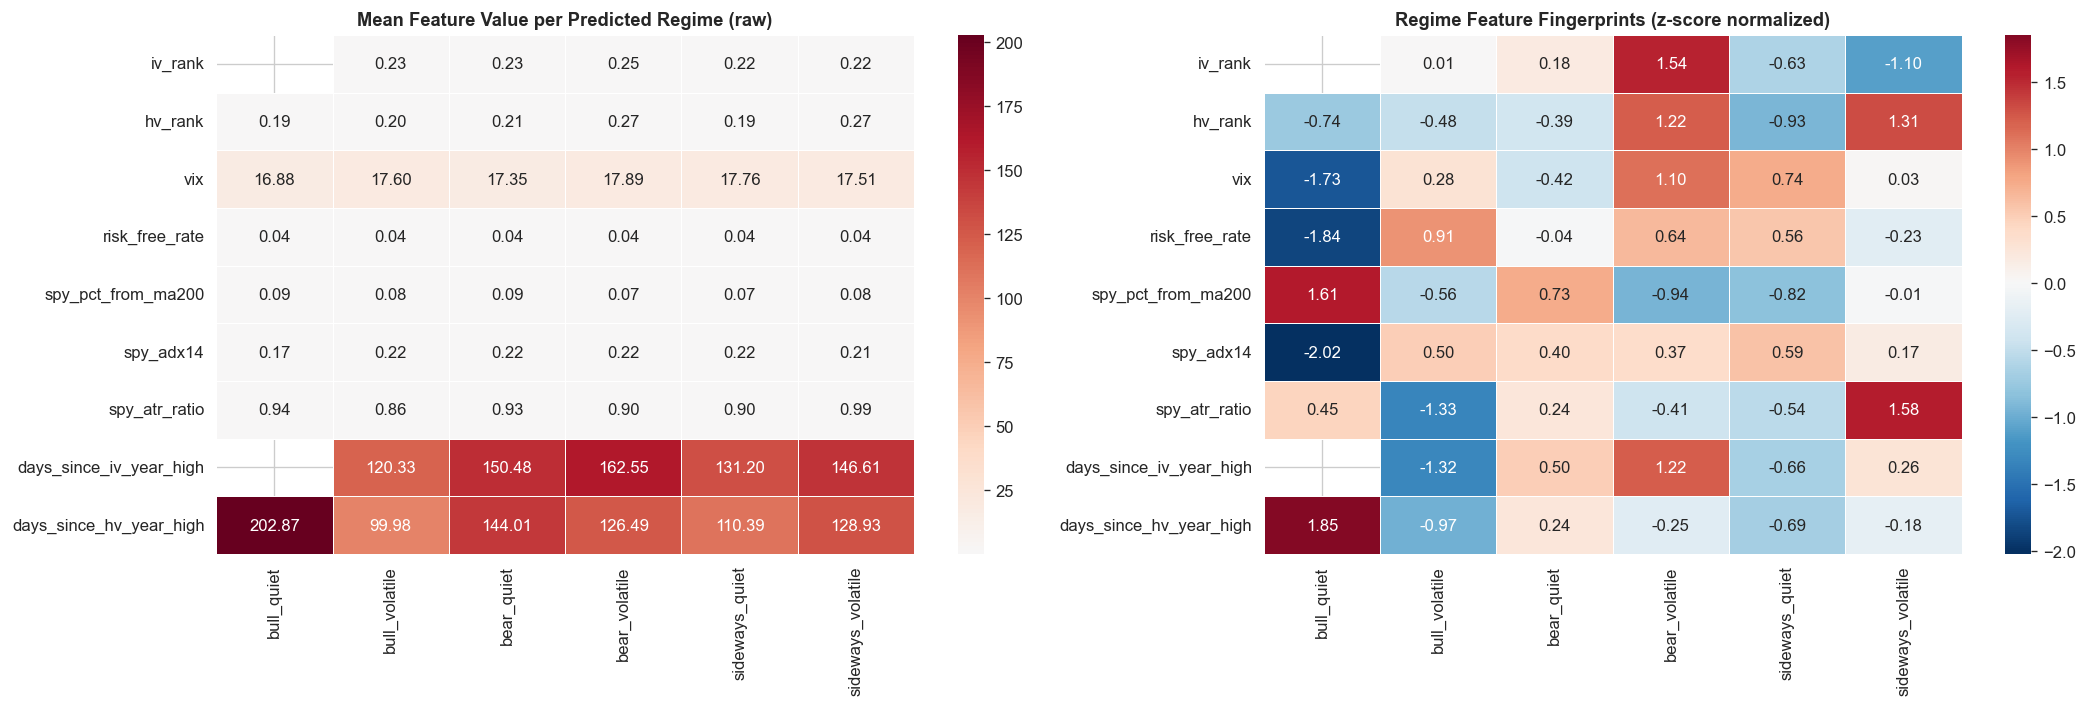

In [45]:
rfm_path = EXP5 / 'regime_feature_means.csv'
if rfm_path.exists():
    rfm = pd.read_csv(rfm_path, index_col=0)

    plot_features = ['iv_rank','hv_rank','vix','risk_free_rate',
                     'spy_pct_from_ma200','spy_adx14','spy_atr_ratio',
                     'days_since_iv_year_high','days_since_hv_year_high']
    plot_features = [f for f in plot_features if f in rfm.columns]
    rfm_sub  = rfm[plot_features]
    rfm_norm = (rfm_sub - rfm_sub.mean()) / (rfm_sub.std() + 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.heatmap(rfm_sub.T, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, ax=axes[0], linewidths=0.5)
    axes[0].set_title('Mean Feature Value per Predicted Regime (raw)', fontsize=11, fontweight='bold')

    sns.heatmap(rfm_norm.T, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, ax=axes[1], linewidths=0.5)
    axes[1].set_title('Regime Feature Fingerprints (z-score normalized)', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print(f'regime_feature_means.csv not found at {rfm_path}')

---
## 20. Key Insights Summary

In [46]:
print('=' * 72)
print('SURFACEALPHA V5 — KEY INSIGHTS')
print('=' * 72)

mz = eval5['mincer_zarnowitz']
bl = eval5['baseline_metrics']

print(f"""
1. CALIBRATION
   MZ slope: V4={eval4['mincer_zarnowitz']['slope']:.4f} -> V5={mz['slope']:.4f} (ideal=1.0)
   MZ R2: {mz['r2']:.4f} (n={mz['n']:,}, F={mz['f_stat']:.0f})

2. HONEST BASELINE COMPARISON
   HAR-RV qlike: {bl['har_rv']['qlike']['mean']:.3f}  V5: {eval5['aggregate']['vol_qlike']['mean']:.3f}
   HAR-RV R2: {bl['har_rv']['r2']['mean']:.3f}  V5: {eval5['aggregate']['vol_r2']['mean']:.3f}
   V5 value-add is in regime conditioning, tail detection, and portfolio integration.

3. MACRO FEATURE EXPANSION (V5)
   spy_adx14 is top gating feature for all experts
   MZ slope improvement: {eval4['mincer_zarnowitz']['slope']:.3f} -> {mz['slope']:.3f}

4. PORTFOLIO PERFORMANCE
   Sharpe: V5={bt5['sharpe']:.3f} vs V4={bt4['sharpe']:.3f} vs BH={bmark['buy_and_hold']['sharpe']:.3f}
   Max DD: V5={bt5['max_drawdown_pct']:.1f}% vs BH={bmark['buy_and_hold']['max_drawdown_pct']:.1f}%
   DD reduction: {abs(bt5['max_drawdown_pct']-bmark['buy_and_hold']['max_drawdown_pct']):.1f} pp
""")

SURFACEALPHA V5 — KEY INSIGHTS

1. CALIBRATION
   MZ slope: V4=0.9730 -> V5=1.0351 (ideal=1.0)
   MZ R2: 0.3722 (n=17,211, F=728)

2. HONEST BASELINE COMPARISON
   HAR-RV qlike: -3.703  V5: -3.594
   HAR-RV R2: 0.116  V5: 0.086
   V5 value-add is in regime conditioning, tail detection, and portfolio integration.

3. MACRO FEATURE EXPANSION (V5)
   spy_adx14 is top gating feature for all experts
   MZ slope improvement: 0.973 -> 1.035

4. PORTFOLIO PERFORMANCE
   Sharpe: V5=0.555 vs V4=0.530 vs BH=0.423
   Max DD: V5=-27.4% vs BH=-40.7%
   DD reduction: 13.3 pp

